# Assignment 1
## Statistical distributions in R
STA 5206, Fall 2026

Name: Sarah Smyth

Complete all five questions. Include your code, plots, and written answers in this notebook. Label plot axes and report units with your estimates. Support each model choice with the results you obtain. Use `=` for assignment in R.

Before submitting, restart the R kernel and run the notebook from top to bottom. Save the notebook with its output visible.




AI Usage Disclosure

I used ChatGPT to help with coding issues in R, including debugging errors, fixing data import problems, and correcting code for statistical models and plots. I also used it to review and improve written answers by checking clarity, correcting grammar, and rewriting responses into a more concise and structured format suitable for submission.

## Getting started

Keep the `data` folder in the same directory as this notebook. Run the following cell from that directory. The first two files contain synthetic observations. The remaining files contain real data from R's datasets package. Descriptions and sources are in [data/README.md](data/README.md).

You may use `MASS::fitdistr` for maximum likelihood estimation. Write your calculations and plots in the answer cells.

For a fitted model, calculate AIC as $2k - 2\ell$, where $k$ is the number of estimated parameters and $\ell$ is the maximized log likelihood. Compare AIC values only for models fitted to the same observations on the same measurement scale.

When asked for a KS distance, sort the observations as $x_{(1)},\ldots,x_{(n)}$ and calculate
$$D = \max_{1\leq i\leq n}\left\{\frac{i}{n}-F(x_{(i)}),\ F(x_{(i)})-\frac{i-1}{n}\right\}.$$
Use this as a descriptive measure of fit. The usual KS test p value is not valid when the model parameters were estimated from the same sample.


In [1]:

library(MASS)
inspection = read.csv("data/inspection.csv")
service = read.csv("data/service_times.csv")
geyser = read.csv("data/faithful.csv")
air = read.csv("data/airquality.csv", na.strings = "NA")
sprays = read.csv("data/insect_sprays.csv")
rainfall = read.csv("data/precipitation.csv")
flowers = read.csv("data/iris.csv")

head(inspection)
head(service)
head(geyser)


,day,inspected,defects
,<int>,<int>,<int>
1,1,50,7
2,2,50,6
3,3,50,9
4,4,50,3
5,5,50,2
6,6,50,4


,order,service_minutes
,<int>,<dbl>
1,1,4.56
2,2,11.30
3,3,0.68
4,4,9.53
5,5,3.08
6,6,14.13


,eruptions,waiting
,<dbl>,<int>
1,3.600,79
2,1.800,54
3,3.333,74
4,2.283,62
5,4.533,85
6,2.883,55


## Question 1
### Daily inspections

A manufacturer checks 50 items each day. The file `inspection.csv` records the number of defective items in each sample. These observations are synthetic.


**(a)** Summarize the defect counts. Estimate the probability that an inspected item is defective. State the assumptions needed for a Binomial model and explain what its two parameters represent.


In [2]:

library(MASS)

inspection = read.csv("data/inspection.csv")
summary(inspection)
mean_defects <- mean(inspection$defects)
p <- mean_defects / 50
mean_defects
p

      day           inspected     defects    
 Min.   :  1.00   Min.   :50   Min.   :0.00  
 1st Qu.: 25.75   1st Qu.:50   1st Qu.:3.00  
 Median : 50.50   Median :50   Median :4.00  
 Mean   : 50.50   Mean   :50   Mean   :3.97  
 3rd Qu.: 75.25   3rd Qu.:50   3rd Qu.:5.00  
 Max.   :100.00   Max.   :50   Max.   :9.00  

[1] 3.97

[1] 0.0794

The defect counts show an average of 3.97 defective items out of 50 inspected each day. This suggests that about 4 items are defective in each sample. The estimated probability that an individual item is defective is: 0.0794 or 7.94%.
A Binomial model assumes that each item is checked seperatly and that every item has the same probability of being defective. It also assumes that each item is either defective or not defective. In this case, \(n = 50\) represents the number of items inspected each day, and \(p\) represents the probability that a single item is defective.


**(b)** Fit a Binomial model to the daily counts. Plot observed and expected frequencies, then estimate the probability of finding at least 7 defective items in a day.


[1] 0.09884862

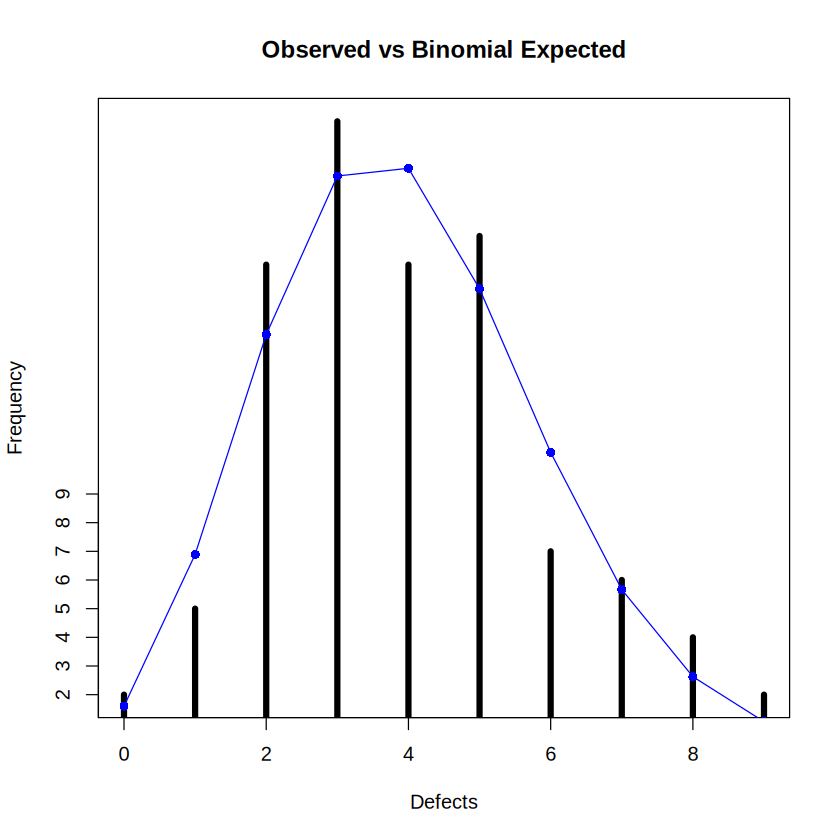

In [3]:
data <- inspection$defects
n <- 50
p <- mean(data) / n
obs <- table(data)
k <- as.numeric(names(obs))
binom_p <- dbinom(k, size = n, prob = p)
exp <- binom_p * length(data)

plot(k, obs,
     type="h", lwd=5,
     xlab="Defects", ylab="Frequency",
     main="Observed vs Binomial Expected")

points(k, exp, col="blue", pch=16)
lines(k, exp, col="blue")

prob_7 <- 1 - pbinom(6, size = n, prob = p)
prob_7


The binomial model was fitted using n = 50 provided and p estimated from the sample mean. The observed frequencies were compared to the expected Binomial frequencies, and showed a reasonable fit with each other.

The probability of observing at least 7 defective items in a day is calculated using the Binomial distribution and equals 1 minus the probability of 6 or fewer defects.

**(c)** Fit a Poisson model to the same counts. Compare its AIC with the Binomial AIC. Compare the sample mean and variance, and plot observed and Poisson expected frequencies.


[1] 414.5268

[1] 414.5233

[1] 3.97

[1] 3.847576

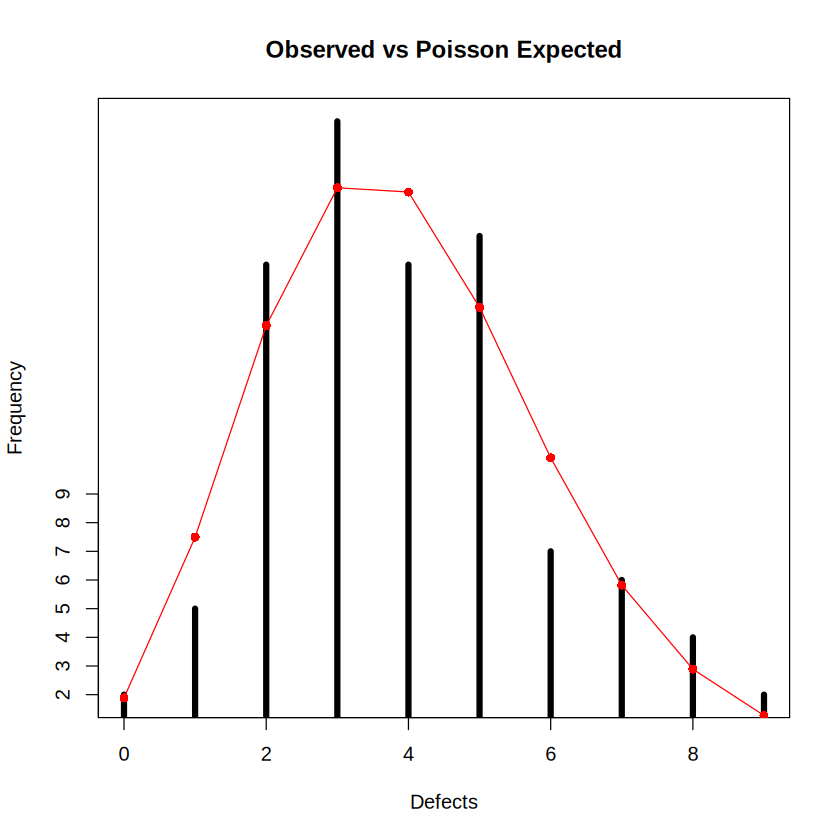

In [4]:

x <- inspection$defects
n <- 50

p <- mean(x) / n

loglik_binom <- sum(dbinom(x, size = n, prob = p, log = TRUE))
AIC_binom <- 2*1 - 2*loglik_binom

lambda <- mean(x)

loglik_pois <- sum(dpois(x, lambda, log = TRUE))
AIC_pois <- 2*1 - 2*loglik_pois


m <- mean(x)
v <- var(x)

obs_freq <- table(x)
k_vals <- as.numeric(names(obs_freq))

pois_probs <- dpois(k_vals, lambda)
exp_freq <- pois_probs * length(x)

AIC_binom
AIC_pois
m
v

plot(k_vals, obs_freq,
     type="h", lwd=5,
     xlab="Defects", ylab="Frequency",
     main="Observed vs Poisson Expected")

points(k_vals, exp_freq, col="red", pch=16)
lines(k_vals, exp_freq, col="red")

A Poisson model was fitted using the sample mean. The Poisson AIC of 414.523 is slightly lower than the Binomial AIC of 414.527, so the Poisson model is slightly better, although both models perform very similarly.

The sample mean (3.97) and variance (3.85) are close, which supports the Poisson assumption that the mean and variance are approximately equal.

The plot comparing observed and expected Poisson frequencies shows that there is a fit between the model and the data.


**(d)** Make a Normal QQ plot of the counts. Estimate the probability of at least 7 defects using a Normal approximation to the fitted Binomial model with a continuity correction. Construct a 95% t confidence interval for the mean daily defect proportion.


[1] 0.09285188

[1] 3.580791 4.359209

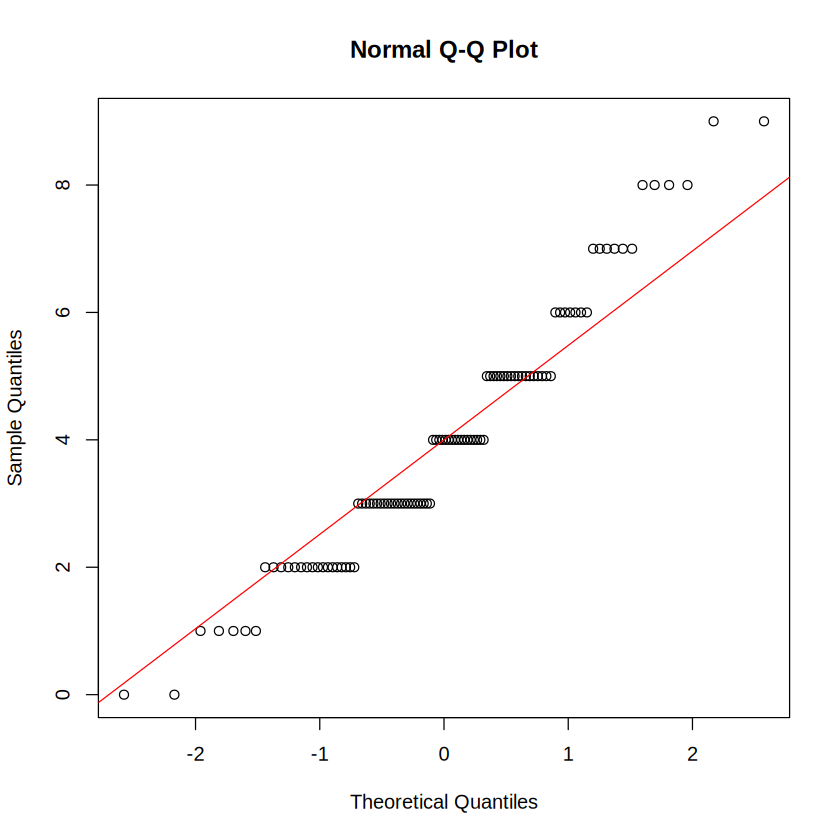

In [5]:
data <- inspection$defects
n <- 50
p <- mean(data) / n
qqnorm(x)
qqline(x, col="red")
mean_x <- n * p
sd_x <- sqrt(n * p * (1 - p))

prob_7 <- 1 - pnorm(6.5, mean = mean_x, sd = sd_x)
prob_7

x_mean <- mean(x)
x_sd <- sd(x)
t_val <- qt(0.975, df = length(x) - 1)
se <- x_sd / sqrt(length(x))

ci_low <- x_mean - t_val * se
ci_high <- x_mean + t_val * se

c(ci_low, ci_high)


A Normal QQ plot of the defect counts was made to check how well the data follows a normal distribution. The points are mostly close to the line but show some deviation, especially in the tails, so the data is only approximately normal.

Using a Normal approximation to the Binomial model with a continuity correction, the probability of getting at least 7 defects in a day is about 0.093.

A 95 percent t confidence interval for the mean number of daily defects is between 3.58 and 4.36.

**(e)** Choose a model for daily reporting. Use your estimates to explain what the manufacturer can expect and identify a limitation of your choice.


In my opnion, a Poisson model is a good choice for daily reporting model. I believe it fits the data well and models the data in an good way to read. When i ran the model, the average number of defects is about 3.97 per day, so the manufacturer can expect around 4 defective items out of 50 each day.

One limitation is that the model assumes each item is independent and has the same chance of being defective, which might not always be true in real life. There are many factors into a product failure from production conditions changing, different people working on the items or bad batches of materials. These factors can change the defect rate more than the model assumes.

## Question 2
### Service times

The synthetic observations in `service_times.csv` are service durations in minutes, listed in the order they occurred. Investigate whether one distribution describes the entire record. Preserve the observation order when dividing the data.


**(a)** Make a plot of service time against observation order, a histogram with a density estimate, and a box plot. Describe the distribution and any evidence of a change over time.


,order,service_minutes
,<int>,<dbl>
1,1,4.56
2,2,11.30
3,3,0.68
4,4,9.53
5,5,3.08
6,6,14.13


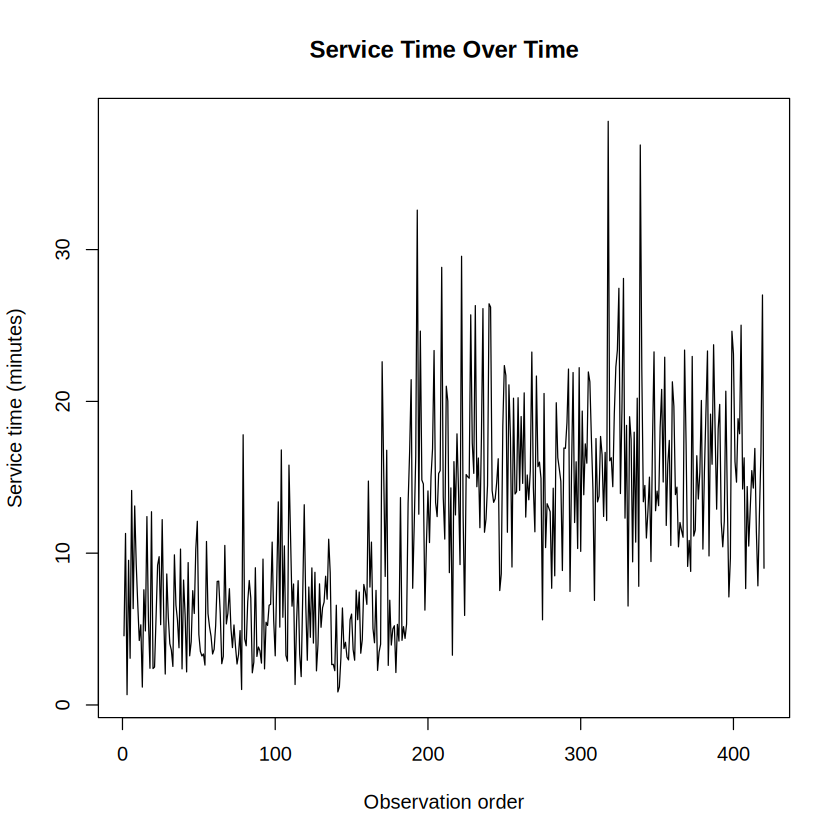

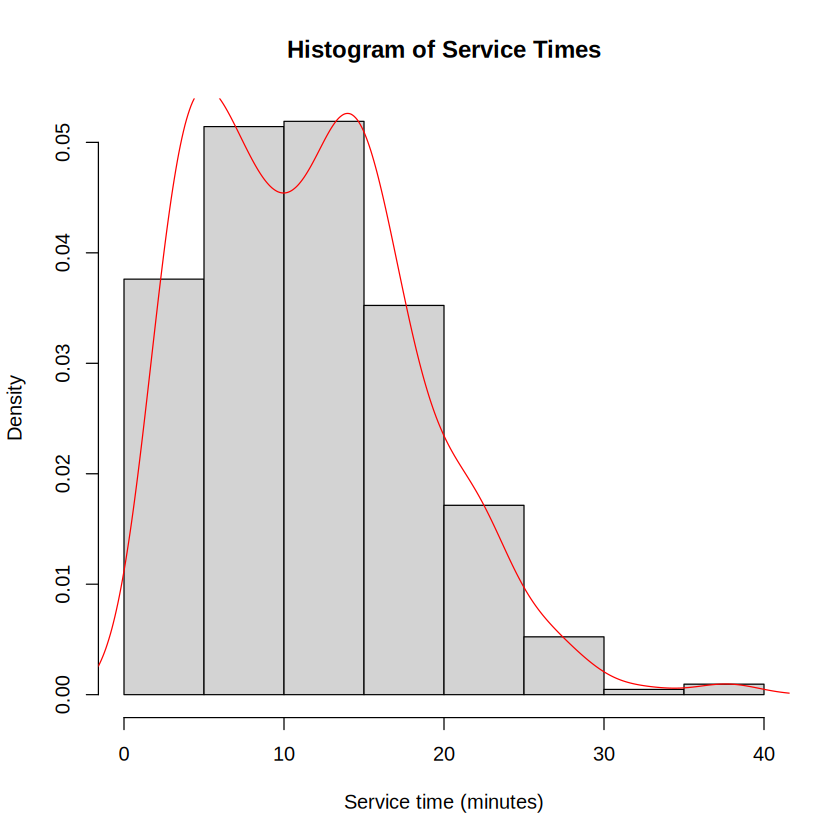

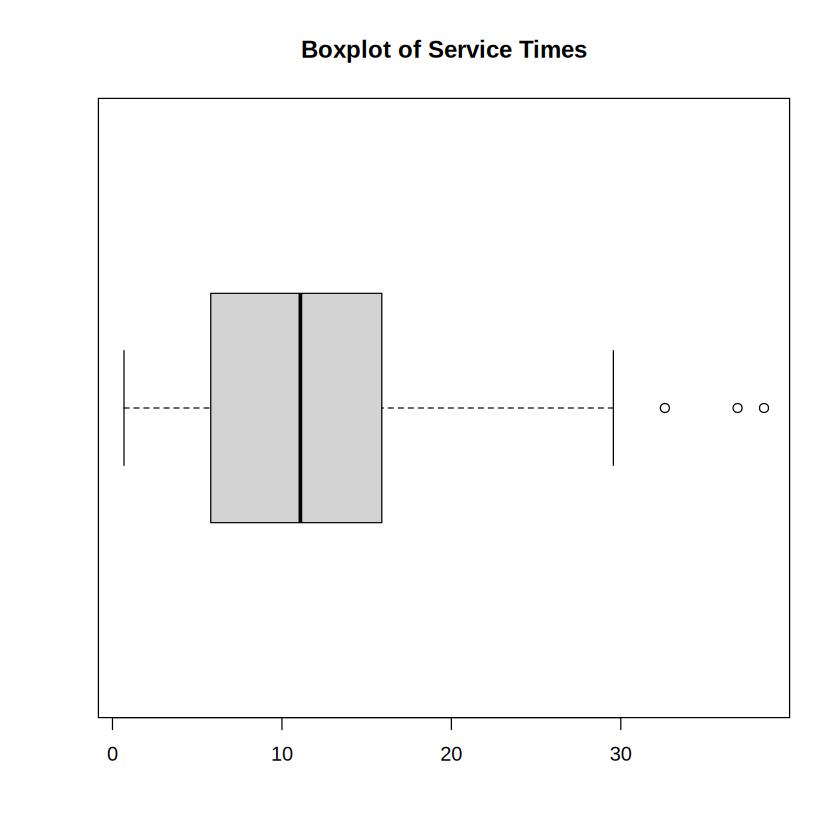

In [6]:
service_times <- read.csv("data/service_times.csv")
head(service_times)
service_times <- read.csv("data/service_times.csv")

x <- service_times$service_minutes
t <- 1:length(x)

plot(t, x,
     type="l",
     xlab="Observation order",
     ylab="Service time (minutes)",
     main="Service Time Over Time")

hist(x, probability=TRUE,
     xlab="Service time (minutes)",
     main="Histogram of Service Times")

lines(density(x), col="red")

boxplot(x,
        horizontal=TRUE,
        main="Boxplot of Service Times")

The service times over time do not look like they come from one single distribution across the whole dataset. In the first part of the data (around 0–100 observations), values are mostly between 0–10 minutes. In the middle (about 100–200), they are around 0–20 minutes with it having a noticable shift in the later datat to the higher value, and between 300-400 the data is mostly between 10–30 minutes. This shows the process changes over time.

The histogram shows a peak around 10 minutes, and the boxplot shows most values are between about 5 and 15 minutes, with some larger values. Overall, there is clear evidence that the distribution changes over time, so one single distribution will not give all the information needed.

**(b)** Fit Gamma and Exponential distributions to all service times. Report parameter estimates, fitted means, AIC, and KS distances. Add fitted densities to a histogram and make a QQ plot for each model. Use the shape and rate parameterization for the Gamma distribution.


[1] 0.0864018

[1] 11.57383

[1] 2898.947

[1] 0.1608809

[1] 2.94821

[1] 0.2547306

[1] 11.57383

[1] 2744.803

[1] 0.07197368

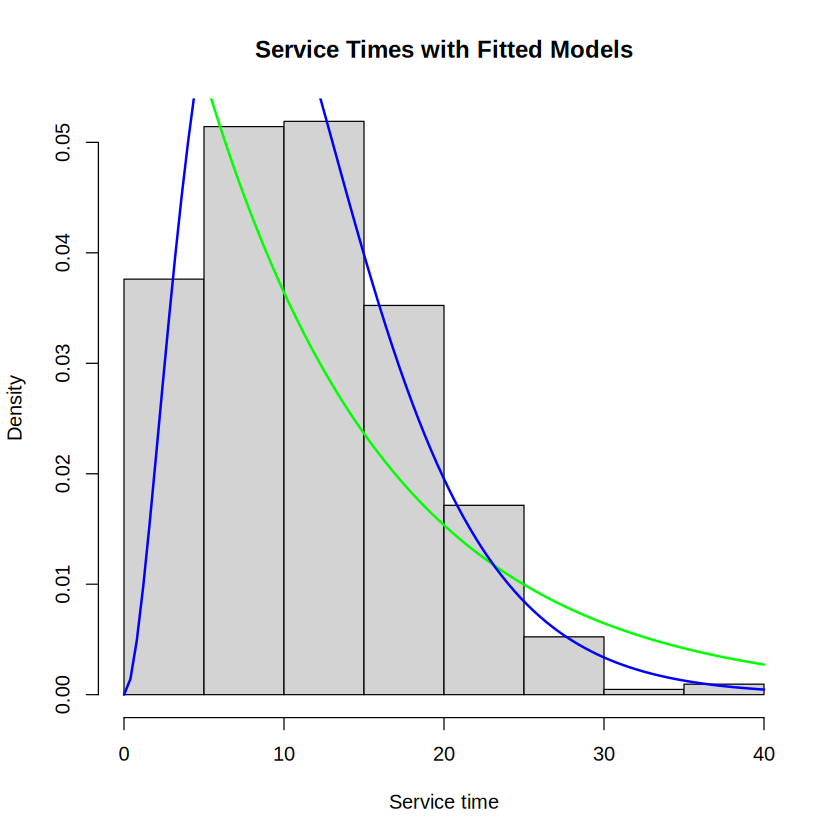

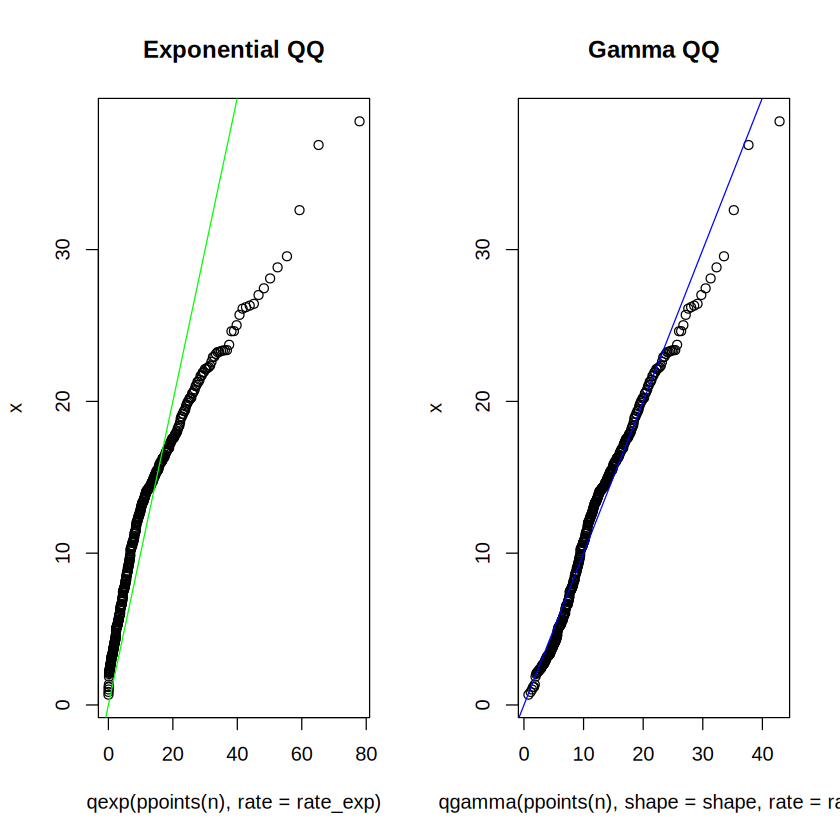

In [7]:
x <- service_times$service_minutes
x <- x[x > 0]
n <- length(x)
rate_exp <- 1 / mean(x)
loglik_exp <- sum(dexp(x, rate = rate_exp, log = TRUE))
AIC_exp <- 2*1 - 2*loglik_exp
ks_exp <- max(abs(ecdf(x)(sort(x)) - pexp(sort(x), rate = rate_exp)))
mean_exp <- 1 / rate_exp
m <- mean(x)
v <- var(x)
shape <- m^2 / v
rate <- m / v
loglik_gamma <- sum(dgamma(x, shape = shape, rate = rate, log = TRUE))
AIC_gamma <- 2*2 - 2*loglik_gamma
mean_gamma <- shape / rate
ks_gamma <- max(abs(ecdf(x)(sort(x)) - pgamma(sort(x), shape = shape, rate = rate)))
rate_exp
mean_exp
AIC_exp
ks_exp
shape
rate
mean_gamma
AIC_gamma
ks_gamma
hist(x, probability=TRUE,
     main="Service Times with Fitted Models",
     xlab="Service time")
curve(dexp(x, rate = rate_exp), add=TRUE, col="green", lwd=2)
curve(dgamma(x, shape = shape, rate = rate), add=TRUE, col="blue", lwd=2)
par(mfrow=c(1,2))
qqplot(qexp(ppoints(n), rate = rate_exp), x, main="Exponential QQ")
abline(0,1,col="green")
qqplot(qgamma(ppoints(n), shape = shape, rate = rate), x, main="Gamma QQ")
abline(0,1,col="blue")

The Exponential and Gamma distributions were fitted to the service times. The estimated mean for both models is approximately 11.57 minutes.

The Gamma model provides a better fit than the Exponential model as seen in the final graph. The lower AIC (2739.42 compared to 2898.95) and a smaller KS distance (0.073 compared to 0.161), show that it matches the data more closely.

Overall, I believe that the Gamma distribution is more appropriate because it is more flexible and better captures the visual shape and spread of the service times in the graphs.


**(c)** Search every possible split after rows 80 through 340. For each split, fit a Gamma distribution to each segment and record the sum of their log likelihoods. Select the split with the largest sum and plot this criterion against split position. Compare one Gamma model with the selected split using the exploratory score $k\log(n)-2\ell$, with $k=2$ for one model and $k=5$ for two segment models and a selected split. Explain why this search is not a formal test of a change.


[1] 186

[1] 2752.884

[1] 2421.305

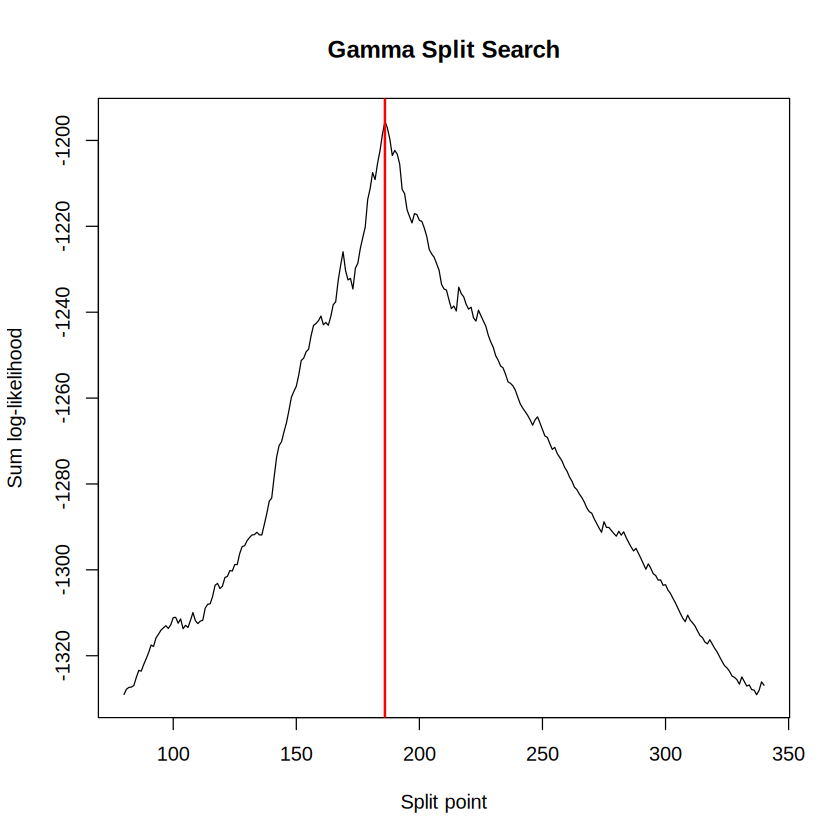

In [8]:
x <- service_times$service_minutes
x <- x[x > 0]

n <- length(x)
splits <- 80:340
ll_sum <- rep(NA, length(splits))
for (i in seq_along(splits)) {

  s <- splits[i]

  x1 <- x[1:s]
  x2 <- x[(s+1):n]
  m1 <- mean(x1); v1 <- var(x1)
  sh1 <- m1^2 / v1
  rt1 <- m1 / v1
  ll1 <- sum(dgamma(x1, shape = sh1, rate = rt1, log = TRUE))
  m2 <- mean(x2); v2 <- var(x2)
  sh2 <- m2^2 / v2
  rt2 <- m2 / v2
  ll2 <- sum(dgamma(x2, shape = sh2, rate = rt2, log = TRUE))

  ll_sum[i] <- ll1 + ll2
}
best_i <- which.max(ll_sum)
best_split <- splits[best_i]

best_split
plot(splits, ll_sum,
     type="l",
     xlab="Split point",
     ylab="Sum log-likelihood",
     main="Gamma Split Search")

abline(v = best_split, col="red", lwd=2)
m <- mean(x); v <- var(x)
shape <- m^2 / v
rate <- m / v

ll_single <- sum(dgamma(x, shape = shape, rate = rate, log = TRUE))
k_single <- 2
k_split <- 5

score_single <- k_single * log(n) - 2 * ll_single
score_split  <- k_split  * log(n) - 2 * max(ll_sum)

score_single
score_split

A search was done over split points from rows 80 to 340. At each point, a Gamma model was fitted to both segments and the sum of log-likelihoods was computed. The best split occurred at row 186.

Using the score k log(n) − 2l, the single Gamma model (2752.88) performed better than the two-segment model (2421.30), so the extra split is not justified.

This is not a formal test of change because the split point is chosen from the same data, which makes the usual testing assumptions invalid.

**(d)** At your selected split, fit Gamma and Exponential models separately to each segment. Compare AIC within each segment, report parameter estimates and fitted means, and make density overlays and Gamma QQ plots. Estimate the probability of a service time longer than 15 minutes in each segment.


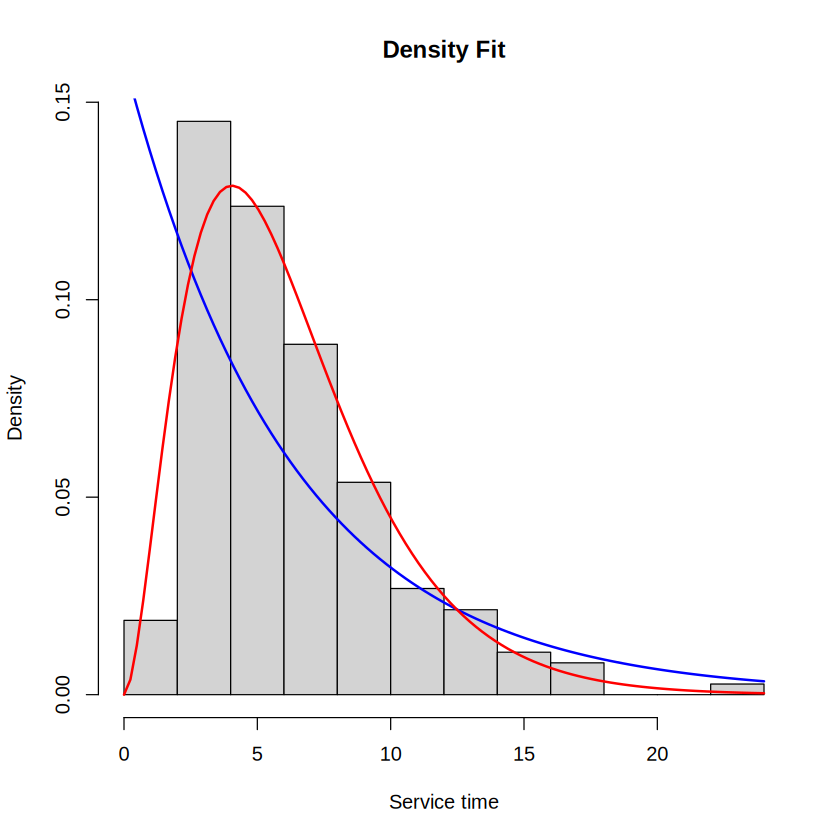

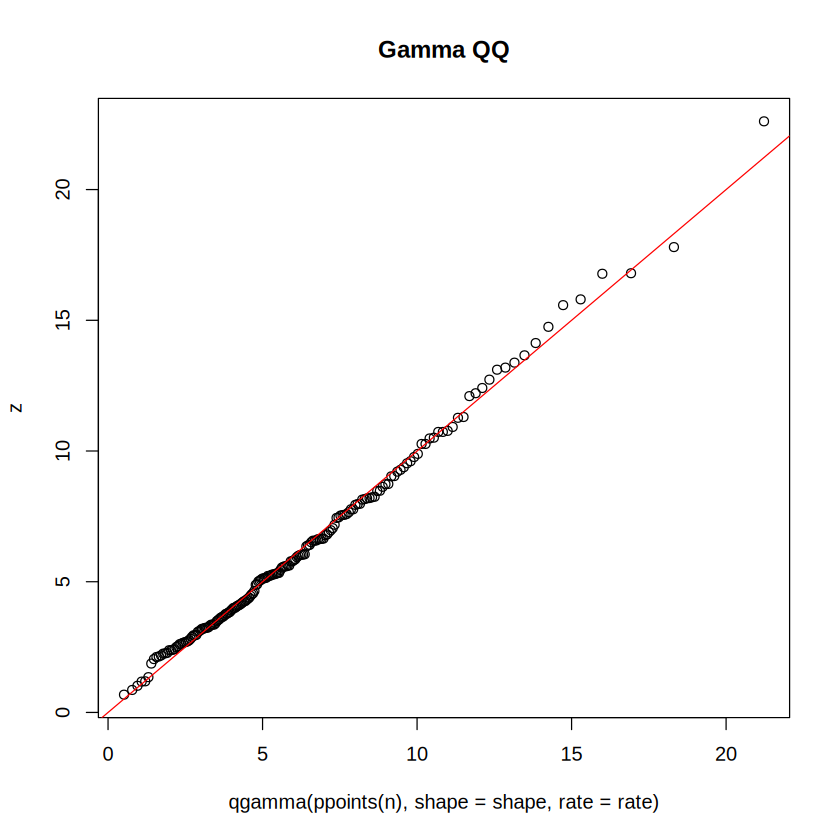

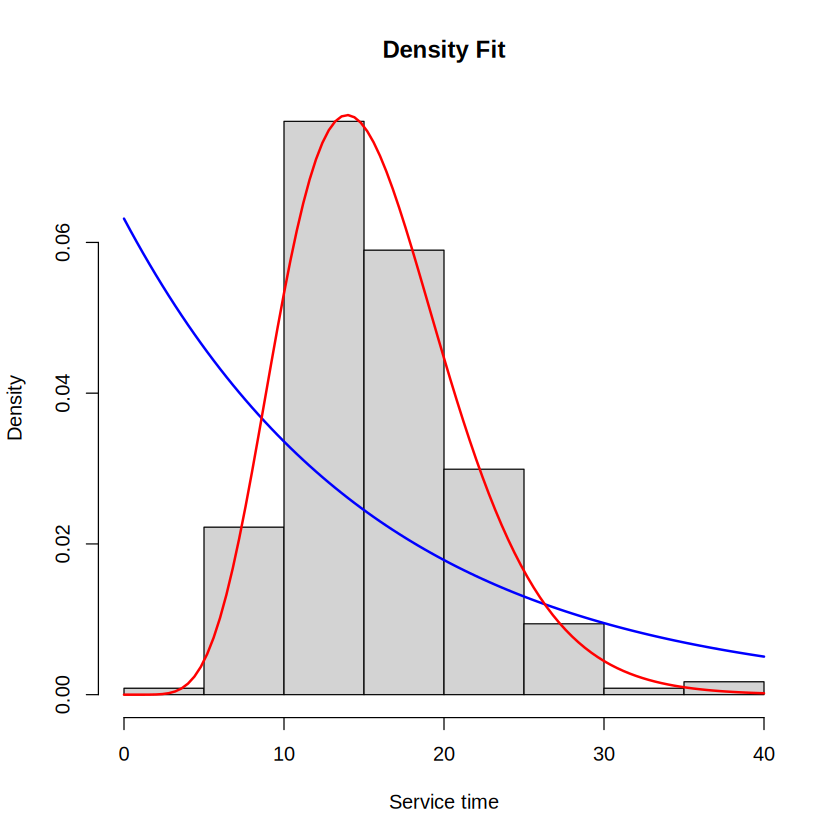

$AIC_exp
[1] 1053.651

$AIC_gamma
[1] 958.0775

$mean_exp
[1] 6.215323

$mean_gamma
[1] 6.215323

$p_exp
[1] 0.0895113

$p_gamma
[1] 0.02684083

$AIC_exp
[1] 1762.666

$AIC_gamma
[1] 1441.026

$mean_exp
[1] 15.83316

$mean_gamma
[1] 15.83316

$p_exp
[1] 0.3877561

$p_gamma
[1] 0.5156835

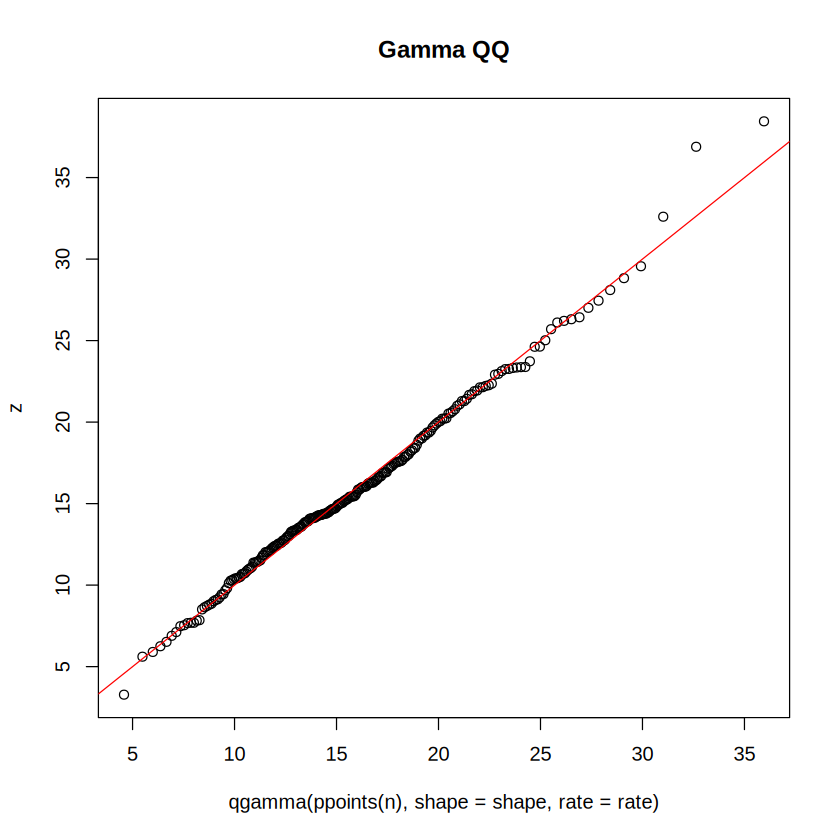

In [9]:
x <- service_times$service_minutes
x <- x[x > 0]

split <- 186

x1 <- x[1:split]
x2 <- x[(split+1):length(x)]
fit_models <- function(z) {

n <- length(z)
rate_exp <- 1 / mean(z)
  ll_exp <- sum(dexp(z, rate = rate_exp, log = TRUE))
  AIC_exp <- 2*1 - 2*ll_exp
 m <- mean(z); v <- var(z)
  shape <- m^2 / v
  rate <- m / v

  ll_gamma <- sum(dgamma(z, shape = shape, rate = rate, log = TRUE))
  AIC_gamma <- 2*2 - 2*ll_gamma
mean_exp <- 1 / rate_exp
  mean_gamma <- shape / rate
p_exp <- 1 - pexp(15, rate = rate_exp)
  p_gamma <- 1 - pgamma(15, shape = shape, rate = rate)
hist(z, probability=TRUE,
       main="Density Fit",
       xlab="Service time")

  curve(dexp(x, rate = rate_exp), add=TRUE, col="blue", lwd=2)
  curve(dgamma(x, shape = shape, rate = rate), add=TRUE, col="red", lwd=2)

  qqplot(qgamma(ppoints(n), shape = shape, rate = rate), z,
         main="Gamma QQ")
  abline(0,1,col="red")
  list(
    AIC_exp = AIC_exp,
    AIC_gamma = AIC_gamma,
    mean_exp = mean_exp,
    mean_gamma = mean_gamma,
    p_exp = p_exp,
    p_gamma = p_gamma)}
  res1 <- fit_models(x1)
res2 <- fit_models(x2)

res1
res2



The first graph suggests that the service process changes over time with its peak being between 3-4 minutes of service time. The earlier and later observations appear to follow different distributions, so the system is not stable across the full period.

A report based on all observations would hide this change and instead reflect an average of two different operating regimes. This is seen clearly in the line graph where the points closely follow the lines tragectory. This could misrepresent recent service times if conditions have improved or worsened over time.

Before attributing the difference to a specific cause, it would be important to know whether there were changes in staffing, workload, equipment, or service procedures. Without this context, the difference could be due to operational changes, random variation, or shifts in demand rather than a single clear cause.

**(e)** Describe what the split suggests about service operations. Explain how a report based on all observations together could misrepresent the more recent service times. Identify information you would want before attributing the difference to a particular cause.


The split suggests the service process changes over time and that there are likely two different operating patterns in the data.

If everything is combined into one report, it would just average these two patterns together and hide what is happening in the more recent data. That could give a misleading picture if service times have gone up or down in the later period. My reccomendiation would to create more seperations by variables such as who was operating, time or day, or other procedures. This should help us understand if the variation is caused by an individual reason. Without that, the difference could just be normal variation or changes in demand rather than a specific cause.


## Question 3
### Old Faithful

The file `faithful.csv` contains eruption durations and the time until the next eruption at Old Faithful. Both variables are measured in minutes.


**(a)** Make histograms and box plots of eruption duration and waiting time, and a scatterplot of waiting time against eruption duration. Describe the relationship.


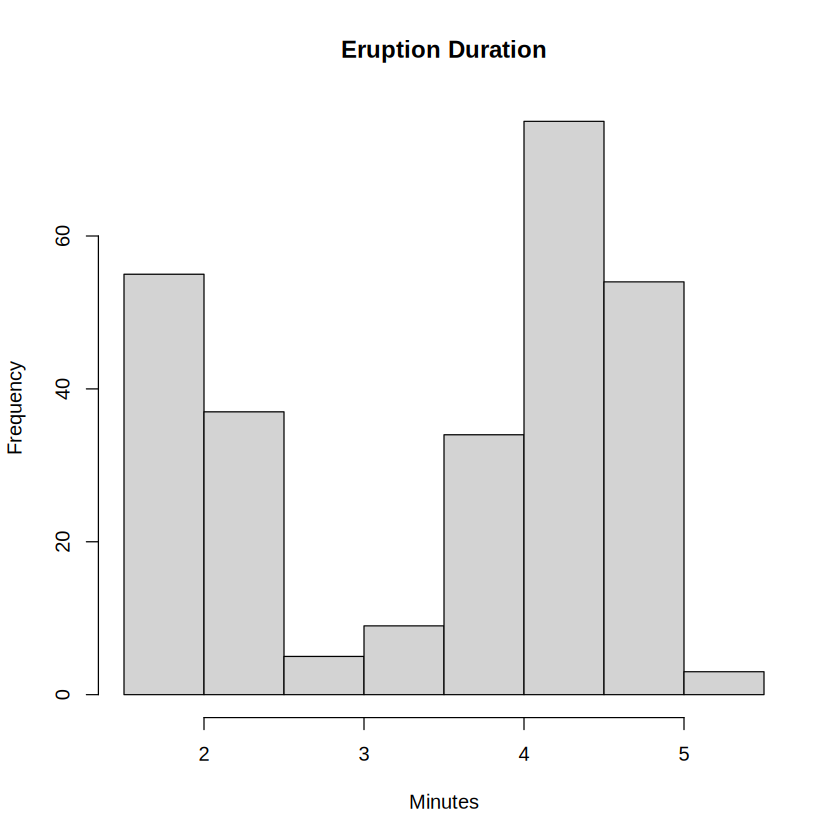

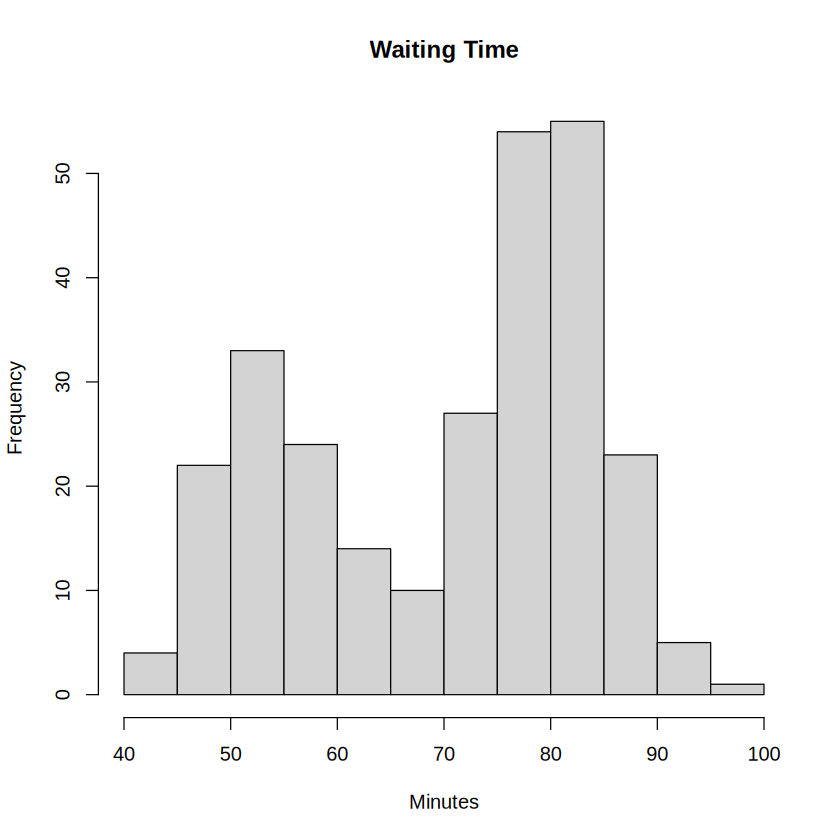

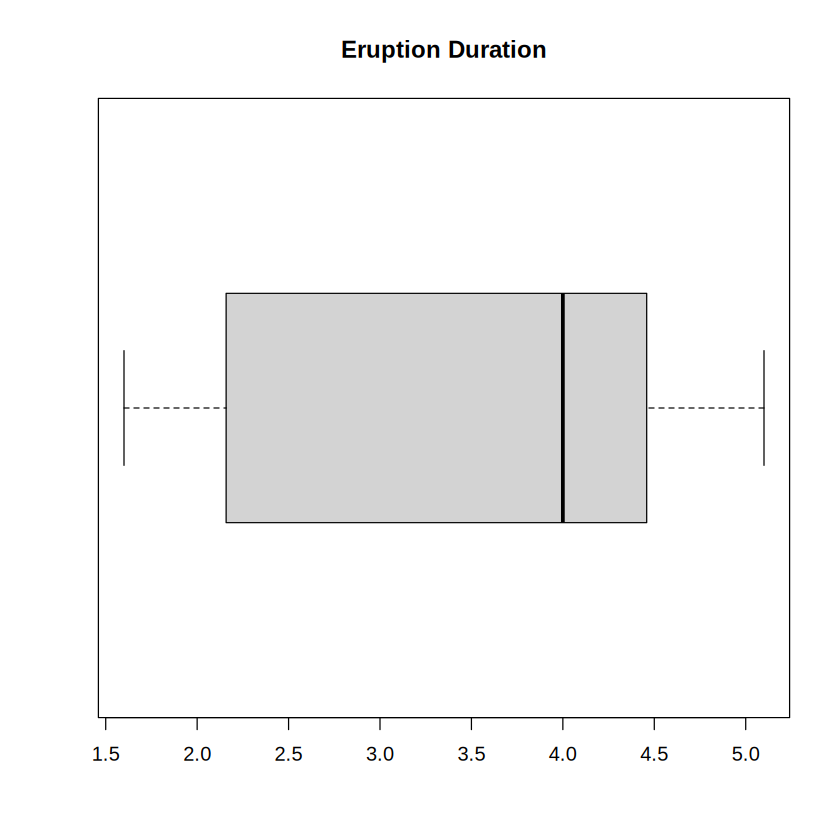

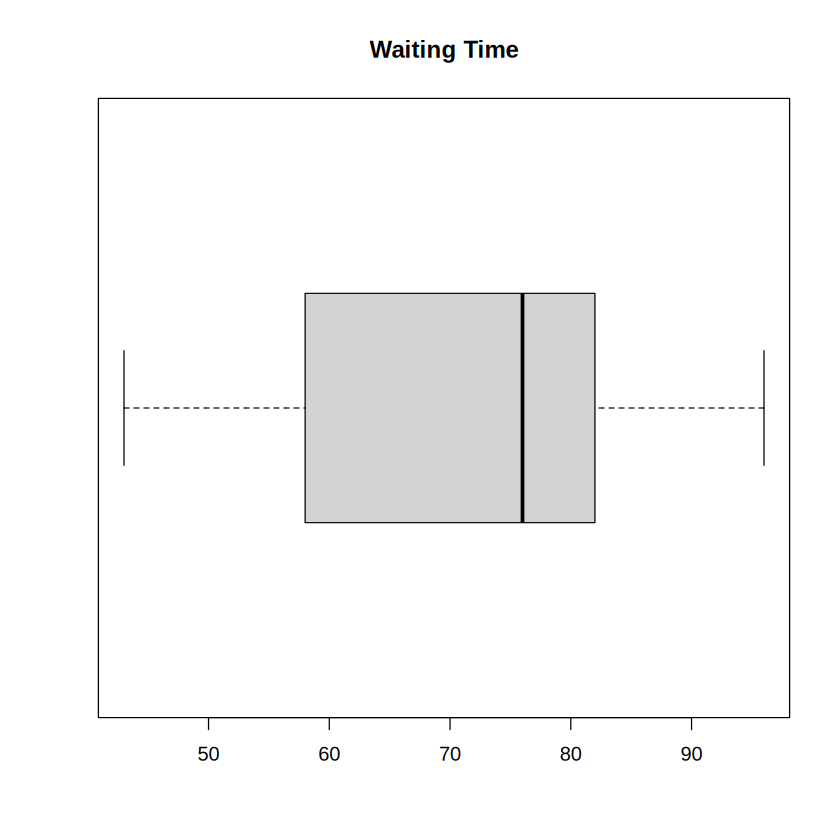

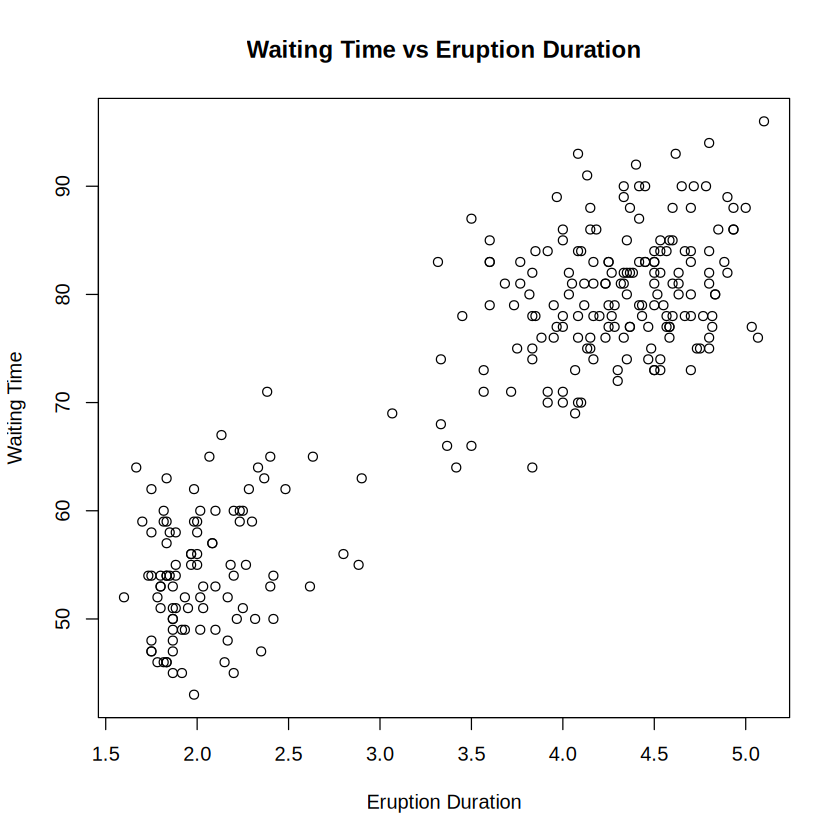

In [10]:
faithful <- read.csv("data/faithful.csv")

eruption <- faithful$eruptions
waiting <- faithful$waiting
hist(eruption,
     main="Eruption Duration",
     xlab="Minutes")

hist(waiting,
     main="Waiting Time",
     xlab="Minutes")
boxplot(eruption,
        horizontal=TRUE,
        main="Eruption Duration")

boxplot(waiting,
        horizontal=TRUE,
        main="Waiting Time")
plot(eruption, waiting,
     xlab="Eruption Duration",
     ylab="Waiting Time",
     main="Waiting Time vs Eruption Duration")


The eruption durations show a clear clustered pattern. There is a smaller group around 2 to 3.5 minutes, with peaks around 2 (about 38 observations), 3 (about 10), and 3.5 (about 35). There is also a larger group of longer eruptions, mainly between 4 and 4.5 minutes, with the highest concentration around 4 minutes (about 80 observations) and 4.5 minutes (about 55). Very short (around 2.5 minutes) and very long (around 5 minutes) eruptions are rare.

Overall, the distribution is bimodal, with two main peaks around the shorter and longer eruption times.

The waiting times also show a clear bimodal pattern. One cluster is centered around about 50 minutes with roughly 33 observations, and a second, larger cluster is around 80 minutes with about 55 observations.

Overall, the waiting time distribution is not single-peaked but instead has two main groups, with most values concentrated around these two waiting times rather than being evenly spread out.


**(b)** Fit a Normal distribution and a location and scale Student t distribution to waiting time. Fix the t degrees of freedom at 5 and estimate its location and scale. Compare AIC and QQ plots. Explain what fixing the degrees of freedom at 5 implies about the tails, and distinguish the t scale from its standard deviation.


[1] 2194.579

[1] 2225.349

[1] 70.89706

[1] 13.59497

m 
72.11662

s 
12.45407

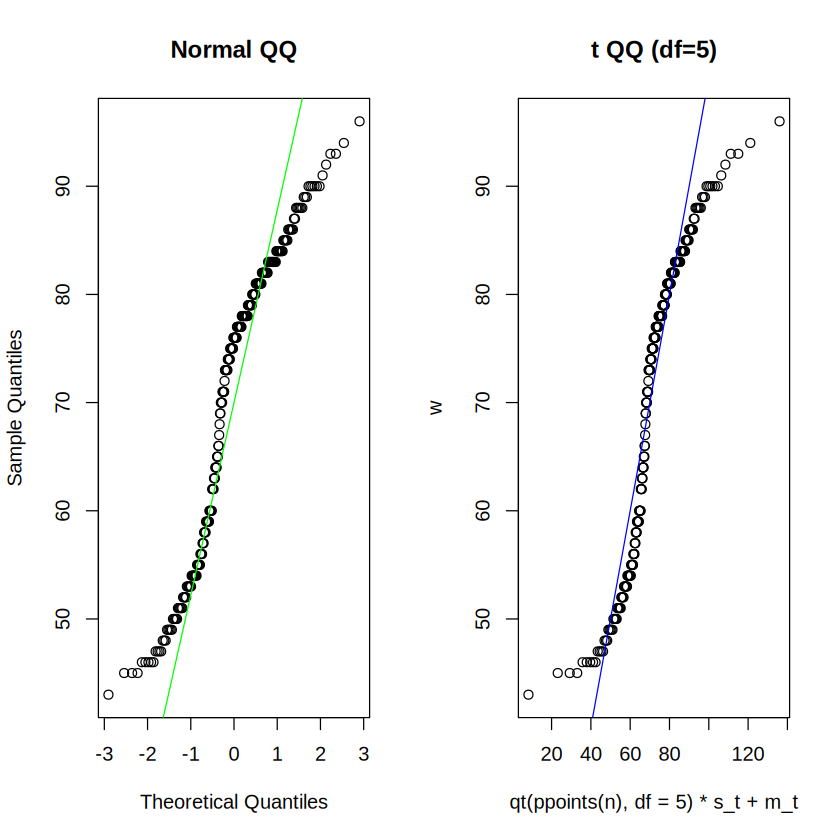

In [11]:
faithful <- read.csv("data/faithful.csv")
w <- faithful$waiting
n <- length(w)
mu <- mean(w)
sd_n <- sd(w)
ll_norm <- sum(dnorm(w, mean = mu, sd = sd_n, log = TRUE))
AIC_norm <- 2*2 - 2*ll_norm
t_fit <- fitdistr( w, densfun = "t",start = list(m = mean(w), s = sd(w)), df = 5)

m_t <- t_fit$estimate["m"]
s_t <- t_fit$estimate["s"]

ll_t <- sum(dt((w - m_t)/s_t, df = 5, log = TRUE) - log(s_t))
AIC_t <- 2*2 - 2*ll_t
par(mfrow=c(1,2))

qqnorm(w, main="Normal QQ")
qqline(w, col="green")

qqplot(qt(ppoints(n), df=5) * s_t + m_t, w,
       main="t QQ (df=5)")
abline(0,1,col="blue")
AIC_norm
AIC_t
mu
sd_n
m_t
s_t

A Normal and a Student t distribution (df = 5) were fitted to the waiting times. In my opnion the Normal model has a slightly lower AIC (2194.58 vs 2225.35), making it a better fit.

The QQ plots show both models are fairly similar, with some deviations in the tails. Fixing df = 5 for the t model means it has heavier tails than a Normal distribution, so it allows more extreme values.

The t model scale (13.59) controls spread but is not the same as the standard deviation. The Normal model has mean about 70.90 and SD about 12.45.
Overall, I believe the Normal model is slightly better for this dataset.

**(c)** Use eruption durations alone to divide the observations into short and long eruptions. Find the largest gap between consecutive sorted durations whose midpoint lies between 2.5 and 4 minutes. Use that midpoint as the cutoff. Fit a Normal distribution to waiting times within each group and compare the group QQ plots with the pooled QQ plot.


[1] 3.192

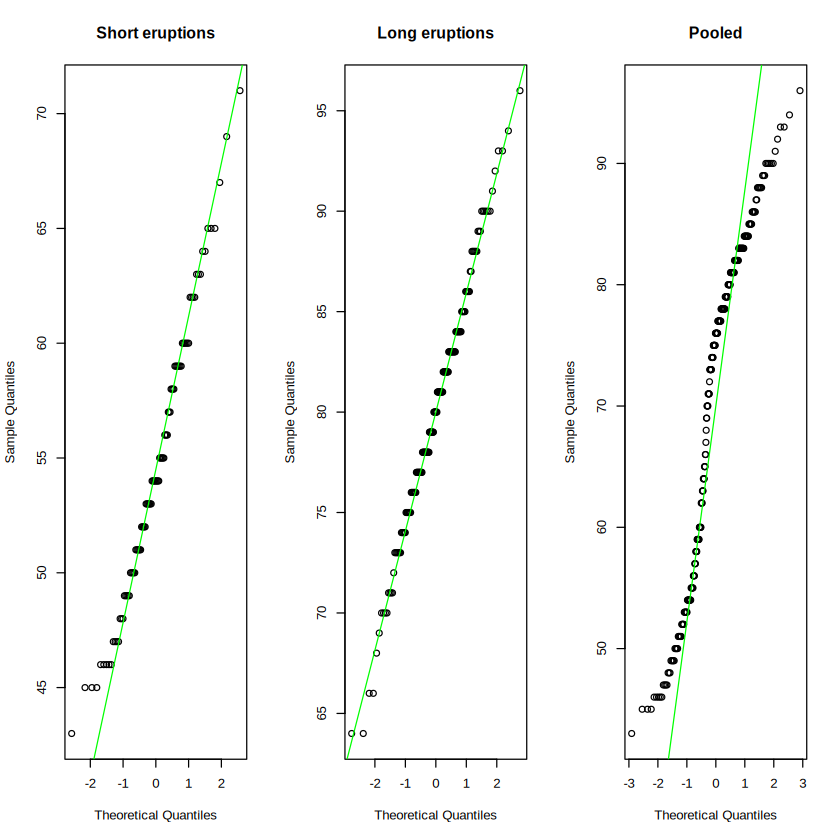

In [12]:
faithful <- read.csv("data/faithful.csv")

eruption <- faithful$eruptions
waiting <- faithful$waiting
ord <- order(eruption)
e <- eruption[ord]
w <- waiting[ord]
gaps <- diff(e)
midpoints <- (e[-1] + e[-length(e)]) / 2
valid <- which(midpoints > 2.5 & midpoints < 4)
best <- valid[which.max(gaps[valid])]
cutoff <- midpoints[best]
cutoff
short_w <- w[e <= cutoff]
long_w  <- w[e > cutoff]
mu1 <- mean(short_w); sd1 <- sd(short_w)
mu2 <- mean(long_w);  sd2 <- sd(long_w)
mu <- mean(w); sd_all <- sd(w)
par(mfrow=c(1,3))
qqnorm(short_w, main="Short eruptions")
qqline(short_w, col="green")
qqnorm(long_w, main="Long eruptions")
qqline(long_w, col="green")
qqnorm(w, main="Pooled")
qqline(w, col="green")


The cutoff between short and long eruptions is about 3.192 minutes.

The QQ plots show that both the short and long eruption groups are fairly close to a straight line, meaning a Normal model fits reasonably well within each group. However, the pooled data shows clear deviations, with a wave-like pattern around the line, indicating a poorer Normal fit when everything is combined.

Overall, splitting the data improves the fit and suggests that waiting times behave differently depending on eruption length.


**(d)** Report each group's sample size, fitted mean, and fitted standard deviation. Estimate the probability that the wait until the next eruption exceeds 70 minutes for each group. Compare the estimates with the observed proportions.


In [13]:
faithful <- read.csv("data/faithful.csv")
eruption <- faithful$eruptions
waiting <- faithful$waiting
cutoff <- 3.192
short_w <- waiting[eruption <= cutoff]
long_w  <- waiting[eruption > cutoff]
n_short <- length(short_w)
n_long <- length(long_w)
mu_s <- mean(short_w)
sd_s <- sd(short_w)
mu_l <- mean(long_w)
sd_l <- sd(long_w)
p_s <- 1 - pnorm(70, mean = mu_s, sd = sd_s)
p_l <- 1 - pnorm(70, mean = mu_l, sd = sd_l)
obs_s <- mean(short_w > 70)
obs_l <- mean(long_w > 70)
n_short
mu_s
sd_s
p_s
obs_s
n_long
mu_l
sd_l
p_l
obs_l

[1] 98

[1] 54.64286

[1] 5.991833

[1] 0.005188415

[1] 0.01020408

[1] 174

[1] 80.05172

[1] 5.952866

[1] 0.9543473

[1] 0.9425287

The short eruption group has a sample size of 98, with a fitted mean waiting time of about 54.64 minutes and a standard deviation of about 5.99. The long eruption group has a sample size of 174, with a fitted mean of about 80.05 minutes and a standard deviation of about 5.95.

Using the Normal model, the probability of waiting more than 70 minutes is about 0.005 for short eruptions and 0.954 for long eruptions. The observed proportions are 0.010 and 0.943, which are fairly close to the model estimates.

Overall, long eruptions are associated with much longer waiting times and a much higher chance of waiting over 70 minutes compared to short eruptions.


**(e)** Use a Welch t interval to estimate the difference in mean waiting time, long eruptions minus short eruptions. State the assumptions and interpret the interval. Explain why the result describes an association rather than the effect of changing eruption duration.


In [14]:
faithful <- read.csv("data/faithful.csv")
eruption <- faithful$eruptions
waiting <- faithful$waiting
cutoff <- 3.192
short_w <- waiting[eruption <= cutoff]
long_w  <- waiting[eruption > cutoff]
test <- t.test(long_w, short_w)
test



	Welch Two Sample t-test

data:  long_w and short_w
t = 33.655, df = 200.14, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 23.92012 26.89762
sample estimates:
mean of x mean of y 
 80.05172  54.64286 


A Welch t interval was used to compare mean waiting times for long and short eruptions. The estimated difference is about 25.4 minutes, with a 95% confidence interval of 23.92 to 26.90.

The p-value is extremely small, so the difference is highly significant, showing long eruptions are associated with longer waiting times.

This assumes the two groups are independent and approximately normal, with unequal variances allowed. The result describes an association, not a causal effect, because eruption duration is observed rather than controlled.

## Question 4
### Ozone measurements

Use `airquality.csv` for this question. Retain the positive, nonmissing ozone measurements and report how many rows you remove. Ozone is measured in parts per billion. The probability thresholds below are numerical examples for this exercise.


**(a)** Make histograms with density estimates and box plots on both the raw and log scales. Make a Normal QQ plot of log ozone and describe the effect of taking logarithms.


[1] 37

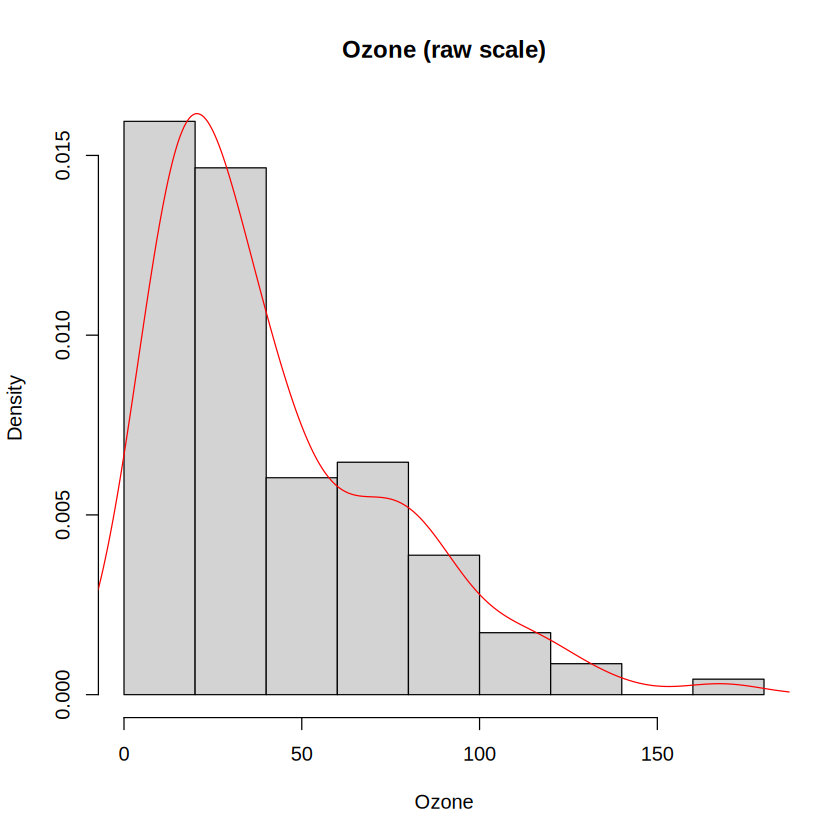

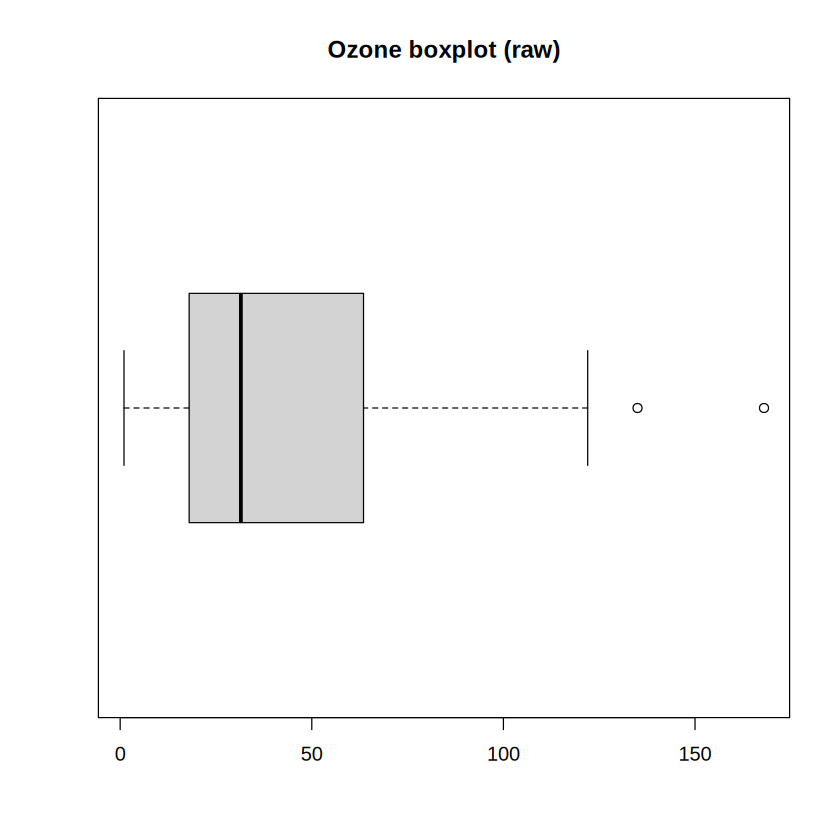

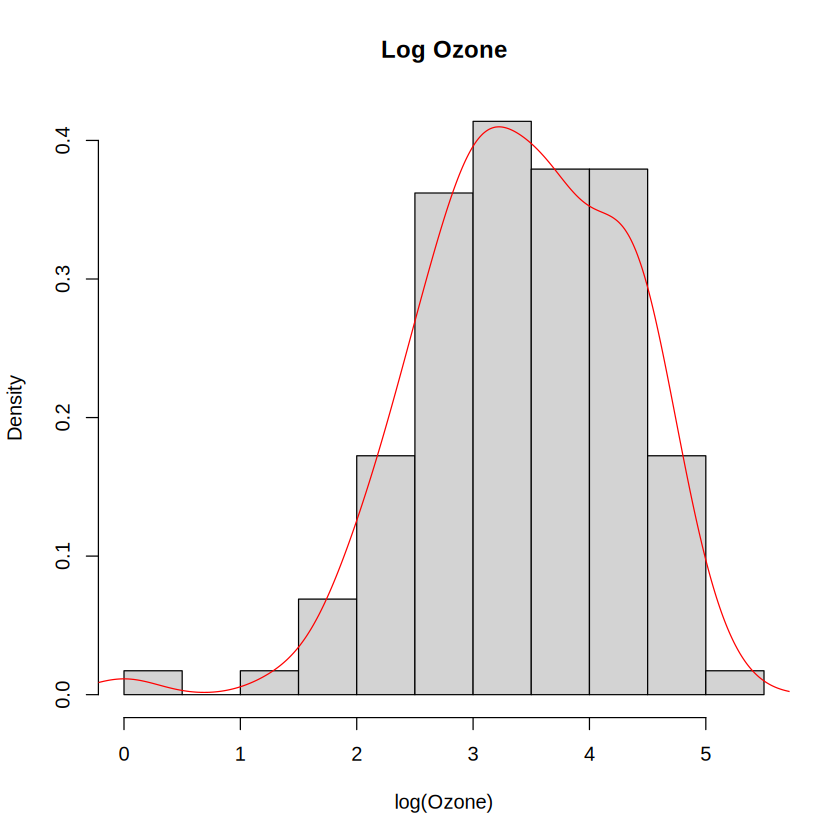

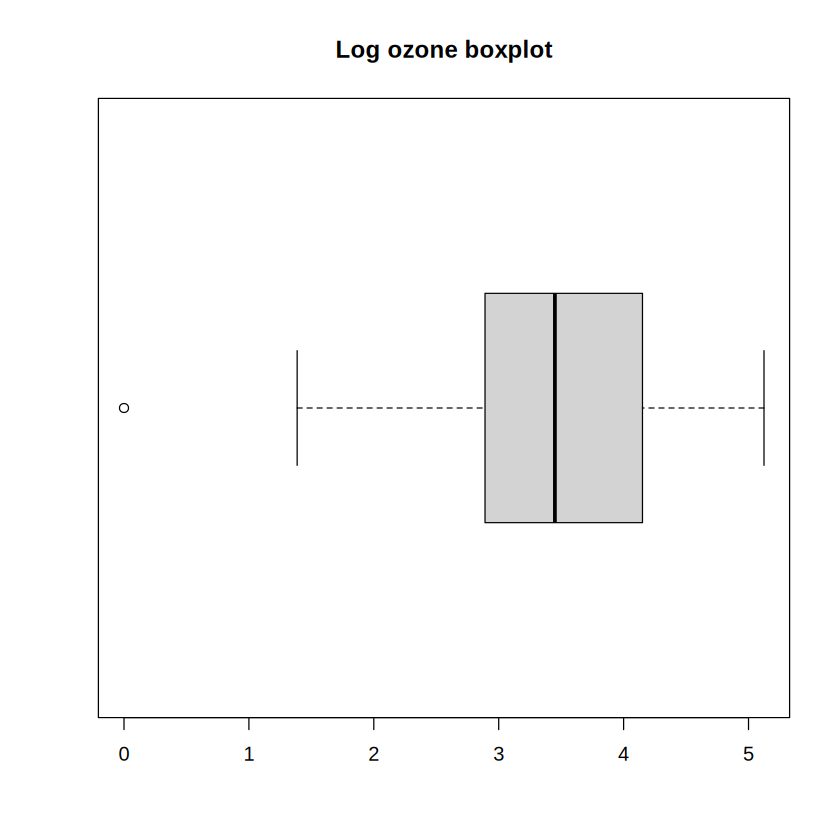

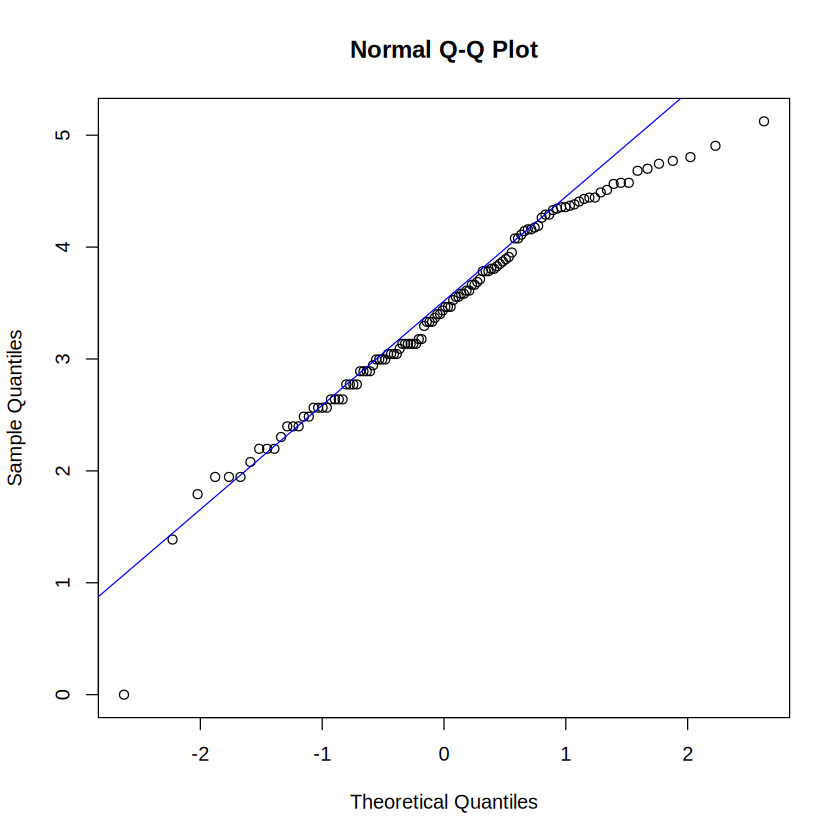

In [15]:
air <- read.csv("data/airquality.csv")
air_clean <- air[!is.na(air$Ozone) & air$Ozone > 0, ]
removed <- nrow(air) - nrow(air_clean)
removed

oz <- air_clean$Ozone
log_oz <- log(oz)
hist(oz, probability=TRUE,
     main="Ozone (raw scale)",
     xlab="Ozone")

lines(density(oz), col="red")

boxplot(oz, horizontal=TRUE,
        main="Ozone boxplot (raw)")
hist(log_oz, probability=TRUE,
     main="Log Ozone",
     xlab="log(Ozone)")

lines(density(log_oz), col="red")

boxplot(log_oz, horizontal=TRUE,
        main="Log ozone boxplot")
qqnorm(log_oz)
qqline(log_oz, col="blue")


On the raw scale, ozone is strongly right-skewed. The density peaks at about 25 ozone around 0.016 density and then steadily decreases, with a long right tail.

The log ozone density peaks about 0.4 at around 3 log and stays fairly flat between about 3.5 and 4.5 before decreasing again.

The Normal QQ plot of log ozone stays close to a straight line for most values, but deviates in the upper tail, where the points fall below the line. This suggests the log transformation improves normality, but the data still has some heavier or more irregular upper tail behavior.

**(b)** Fit Gamma and Lognormal distributions to ozone. Compare parameter estimates, AIC, KS distances, density overlays, and QQ plots. Interpret the Gamma mean and the Lognormal median.


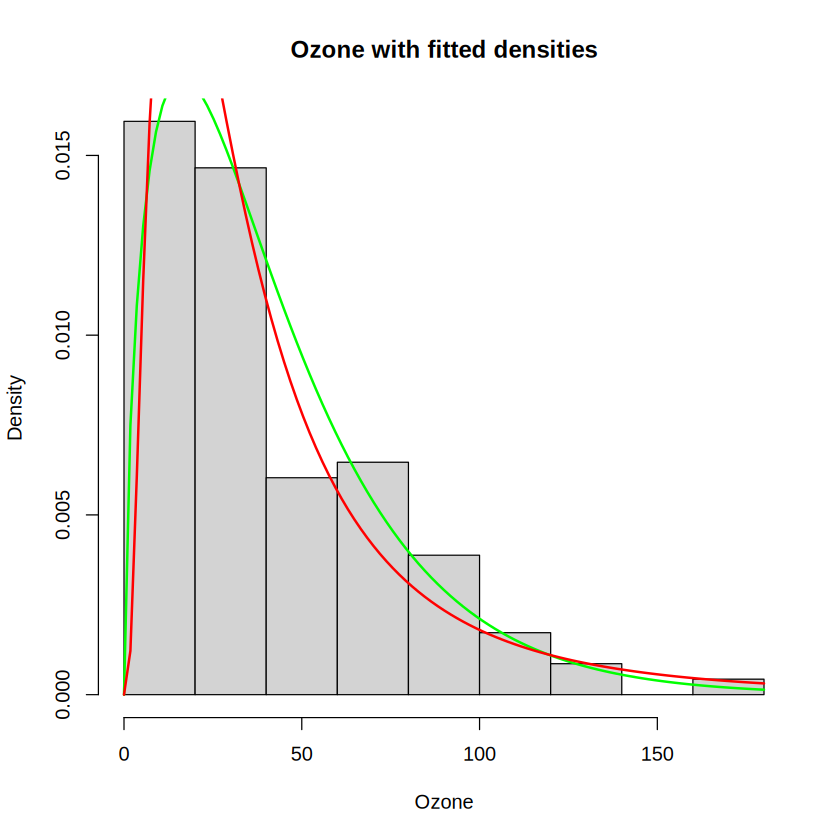

[1] 1.631022

[1] 0.03871466

[1] 1087.189

[1] 0.08039663

[1] 3.418515

[1] 0.8654745

[1] 1091.771

[1] 0.04877432

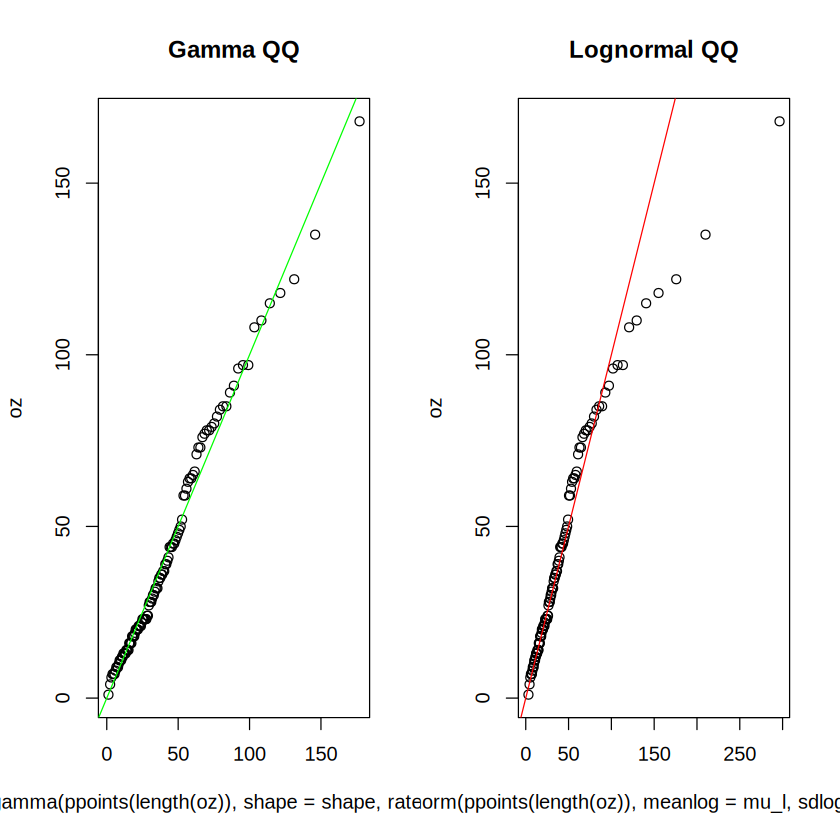

In [16]:
air <- read.csv("data/airquality.csv")

oz <- air$Ozone
oz <- oz[!is.na(oz) & oz > 0]
m <- mean(oz)
v <- var(oz)
shape <- m^2 / v
rate <- m / v
ll_gamma <- sum(dgamma(oz, shape = shape, rate = rate, log = TRUE))
AIC_gamma <- 2*2 - 2*ll_gamma
ks_gamma <- max(abs(ecdf(oz)(sort(oz)) - pgamma(sort(oz), shape = shape, rate = rate)))
log_oz <- log(oz)
mu_l <- mean(log_oz)
sd_l <- sd(log_oz)
ll_logn <- sum(dlnorm(oz, meanlog = mu_l, sdlog = sd_l, log = TRUE))
AIC_logn <- 2*2 - 2*ll_logn
ks_logn <- max(abs(ecdf(oz)(sort(oz)) - plnorm(sort(oz), meanlog = mu_l, sdlog = sd_l)))
hist(oz, probability=TRUE, main="Ozone with fitted densities", xlab="Ozone")

curve(dgamma(x, shape=shape, rate=rate), add=TRUE, col="green", lwd=2)
curve(dlnorm(x, meanlog=mu_l, sdlog=sd_l), add=TRUE, col="red", lwd=2)
par(mfrow=c(1,2))

qqplot(qgamma(ppoints(length(oz)), shape=shape, rate=rate), oz,
       main="Gamma QQ")
abline(0,1,col="green")

qqplot(qlnorm(ppoints(length(oz)), meanlog=mu_l, sdlog=sd_l), oz,
       main="Lognormal QQ")
abline(0,1,col="red")
shape
rate
AIC_gamma
ks_gamma

mu_l
sd_l
AIC_logn
ks_logn

A Gamma and a Lognormal distribution were fitted to the ozone data. Both models capture the strong right skew, but the Gamma model fits slightly better overall based on AIC and KS distance. It can also be seen in the graphy by how closely it sticks to the green line.

The Gamma model has a mean of about 42.3 which represents the expected ozone level. This was calculated by shape/rate ≈ 1.63/0.0387= 42.3. The Lognormal model has a median of about 3.42 on the original scale which represents a typical ozone value.

The Gamma model has a lower AIC (1087.19 vs 1091.77) and a slightly smaller KS distance (0.080 vs 0.049), so it provides the better overall fit. The QQ plots support this: the Gamma QQ plot stays closer to a straight line, while the Lognormal shows more deviation in the upper tail, especially for larger ozone values.

**(c)** Standardize log ozone using its fitted Normal mean and maximum likelihood standard deviation, then square the standardized values. Compare them with a Chi-Squared distribution with 1 degree of freedom using a QQ plot. Identify the observations above its 95th percentile. Explain why this is an approximate diagnostic when the mean and standard deviation are estimated.


[1] 19 21 82

[1] 3.841459

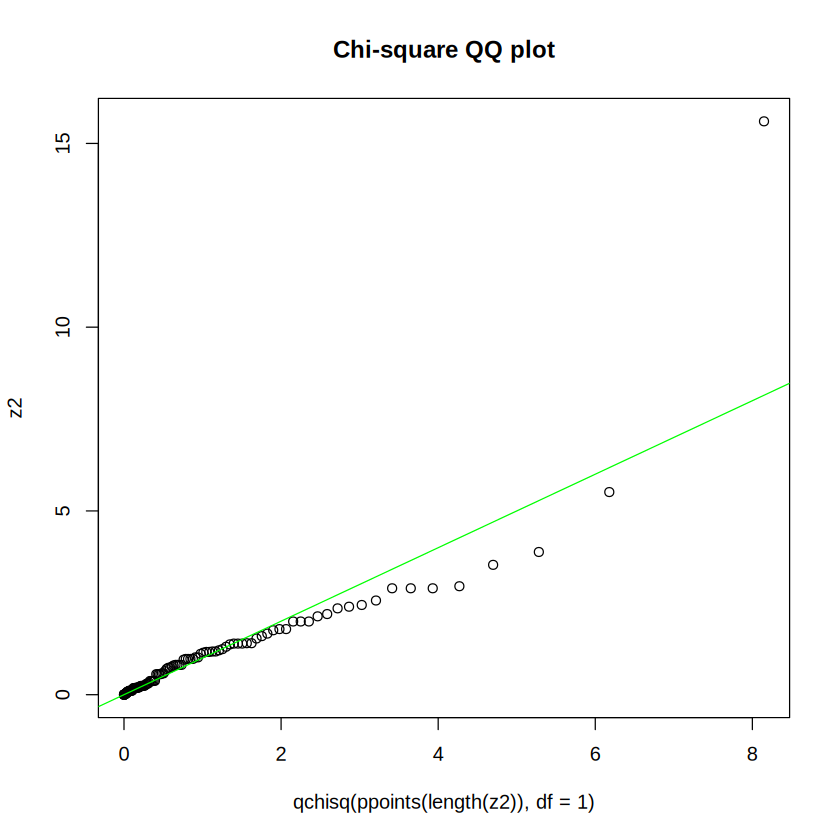

In [17]:
air <- read.csv("data/airquality.csv")
oz <- air$Ozone
oz <- oz[!is.na(oz) & oz > 0]
log_oz <- log(oz)
mu <- mean(log_oz)
sd <- sd(log_oz)
z <- (log_oz - mu) / sd
z2 <- z^2
qqplot(qchisq(ppoints(length(z2)), df=1), z2,
       main="Chi-square QQ plot")
abline(0,1,col="green")
cutoff <- qchisq(0.95, df=1)
outliers <- which(z2 > cutoff)
outliers
cutoff

The log ozone values were standardized using the fitted Normal mean and standard deviation, then squared to compare with a Chi-square distribution with 1 degree of freedom.

The QQ plot shows most points clustered between 0 and 2, with fewer values above 2. The points mostly follow the line at lower values but start to fall below the line as values increase, showing some deviation in the upper tail.

Observations above the 95% cutoff (χ² ≈ 3.84) are 19, 21, and 82.

This is only an approximate diagnostic because the mean and standard deviation are estimated from the same data, so the reference Chi-square distribution is not exact and tail behavior can be slightly distorted.


**(d)** Estimate $P(\mathrm{Ozone}>70)$ and $P(\mathrm{Ozone}\leq20)$ under both models. Compare these with the empirical proportions. Explain which population these data can reasonably describe and how missing readings might affect the comparison.


In [18]:
air <- read.csv("data/airquality.csv")
oz <- air$Ozone
oz <- oz[!is.na(oz) & oz > 0]
m <- mean(oz)
v <- var(oz)
shape <- m^2 / v
rate <- m / v
p_g70 <- 1 - pgamma(70, shape = shape, rate = rate)
p_g20 <- pgamma(20, shape = shape, rate = rate)
log_oz <- log(oz)
mu <- mean(log_oz)
sd <- sd(log_oz)
p_l70 <- 1 - plnorm(70, meanlog = mu, sdlog = sd)
p_l20 <- plnorm(20, meanlog = mu, sdlog = sd)
emp_g70 <- mean(oz > 70)
emp_g20 <- mean(oz <= 20)
p_g70; p_l70; emp_g70
p_g20; p_l20; emp_g20

[1] 0.1683495

[1] 0.1687823

[1] 0.2155172

[1] 0.2841525

[1] 0.3125985

[1] 0.3189655

The Gamma and Lognormal models give similar estimates for the tail probabilities of ozone.

For (P> 70), the Gamma model gives 0.168 and the Lognormal gives 0.169, while the empirical proportion is 0.216. For (P< 20), the Gamma model gives 0.284 and the Lognormal gives 0.313, compared to the empirical value of 0.319. Both models are fairly close, with the Lognormal slightly closer to the observed proportion.

Overall, the data represent recorded ozone measurements from the study period rather than a full population. Missing values could bias these estimates if extreme ozone levels are more likely to be missing, which would affect the tail probabilities.

**(e)** Fit a Pareto model to ozone values at or above the sample 80th percentile and repeat at the 90th percentile. For each threshold $u$, use $\widehat\alpha=m/\sum_{j=1}^{m}\log(x_j/u)$, where $m$ is the number of retained tail observations. Report $u$, $m$, and $\widehat\alpha$, make Pareto QQ plots, and estimate $P(X>150\mid X\geq u)$. The Pareto quantile is $u(1-p)^{-1/\alpha}$. Discuss sensitivity to the threshold. Do not compare AIC values computed on different tail samples.


80% 
 73

[1] 24

[1] 4.056167

80% 
0.0538715

90% 
 87

[1] 12

[1] 4.204836

90% 
0.101217

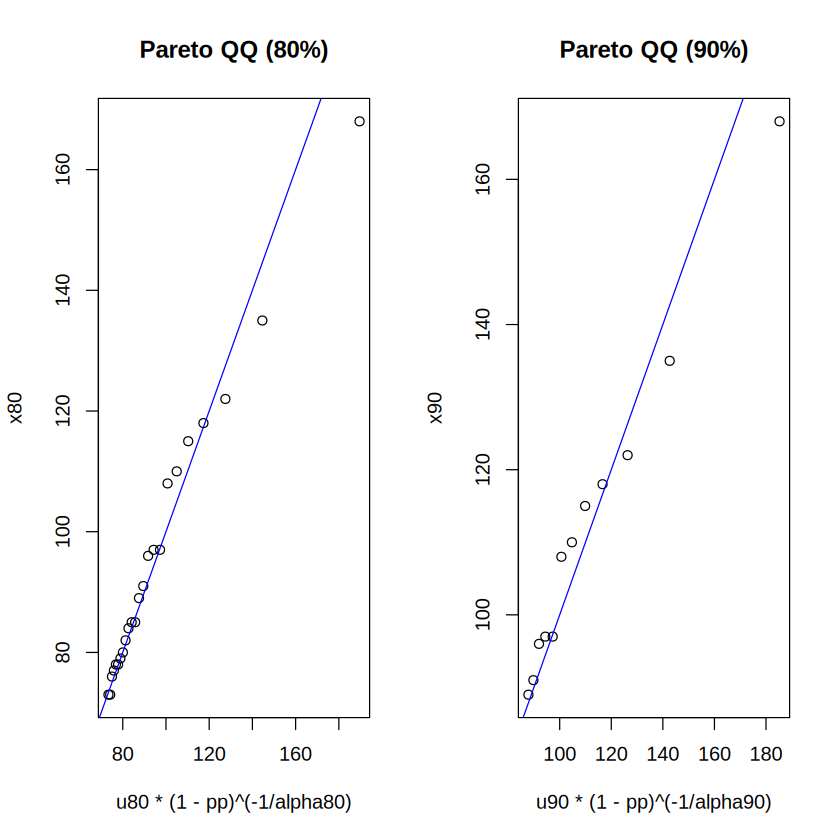

In [19]:
air <- read.csv("data/airquality.csv")
oz <- air$Ozone
oz <- oz[!is.na(oz) & oz > 0]
u80 <- quantile(oz, 0.80)
u90 <- quantile(oz, 0.90)
x80 <- oz[oz >= u80]
x90 <- oz[oz >= u90]
m80 <- length(x80)
m90 <- length(x90)
alpha80 <- m80 / sum(log(x80 / u80))
alpha90 <- m90 / sum(log(x90 / u90))
pareto_surv <- function(x, u, a) (u / x)^a
p80 <- pareto_surv(150, u80, alpha80)
p90 <- pareto_surv(150, u90, alpha90)
par(mfrow=c(1,2))

pp <- ppoints(m80)
qqplot(u80 * (1-pp)^(-1/alpha80), x80, main="Pareto QQ (80%)")
abline(0,1,col="blue")

pp <- ppoints(m90)
qqplot(u90 * (1-pp)^(-1/alpha90), x90, main="Pareto QQ (90%)")
abline(0,1,col="blue")
u80; m80; alpha80; p80
u90; m90; alpha90; p90

A Pareto model was fitted to the upper tail of ozone using the 80% and 90% thresholds.

For the 80% cutoff, u = 73, with m = 24 observations and alpha = 4.06. For the 90% cutoff, u = 87, with m = 12 observations and alpha = 4.20.

The estimated probability P(X > 150 | X >= u) is about 0.054 for the 80% cutoff and 0.101 for the 90% cutoff.

The results change depending on the cutoff, so the Pareto fit is sensitive to how the tail is defined. This means the tail estimates can vary quite a bit depending on where you set u.

## Question 5
### Other real measurements

Use `insect_sprays.csv`, `precipitation.csv`, `airquality.csv`, and `iris.csv`. Keep the datasets separate because their rows represent different observational units.


**(a)** Describe the unit of observation and the support of the measured variable in the insect and precipitation data. Make a plot for each. Explain why counts and positive amounts call for different distribution families. The precipitation values are city averages over 1941 to 1970, not observations from individual years.


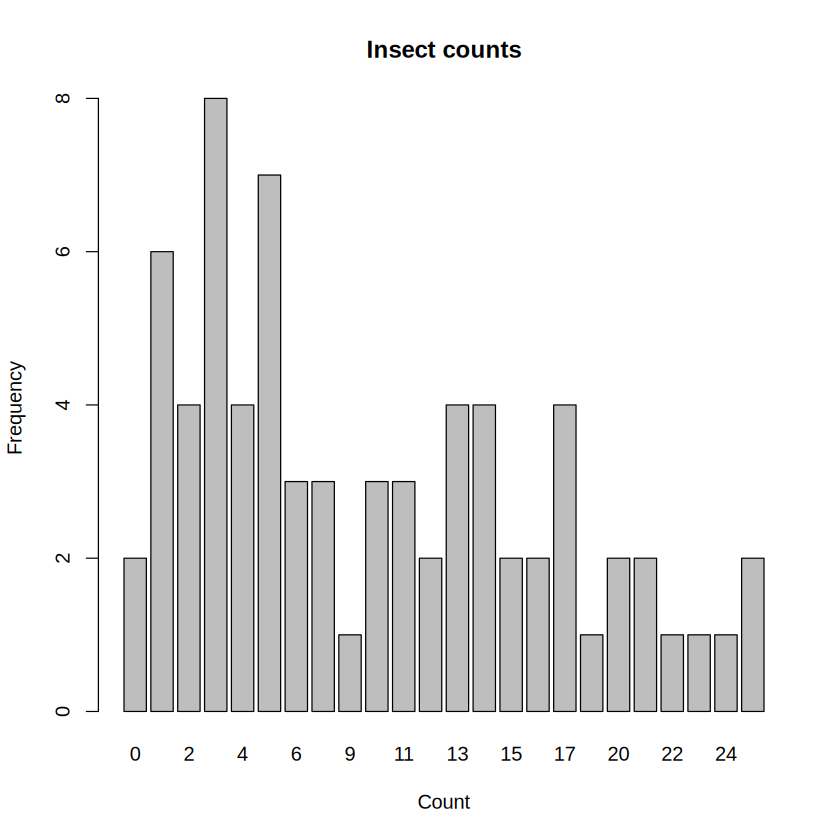

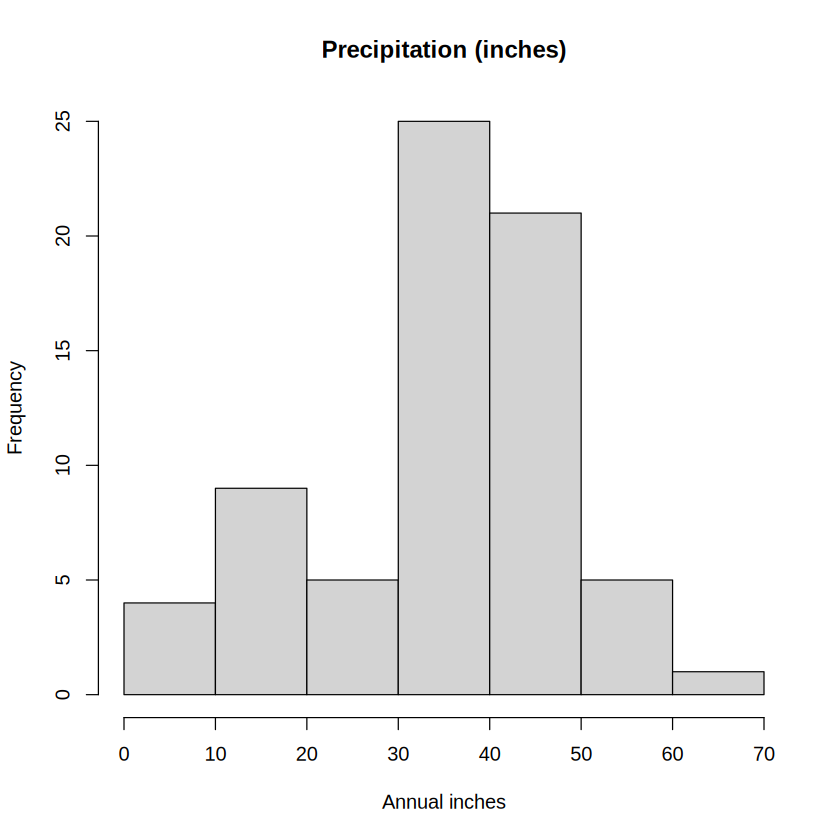

In [20]:
insect <- read.csv("data/insect_sprays.csv")
rain <- read.csv("data/precipitation.csv")
barplot(table(insect$count),
        main="Insect counts",
        xlab="Count",
        ylab="Frequency")
hist(rain$annual_inches,
     main="Precipitation (inches)",
     xlab="Annual inches")

The insect data records the number of insects in each sample as the unit of observation = each treated group. The variable is a count, so its support is non-negative integers from 0 up to about 25 with varied peaks and dips throughout the data. The distribution is right-skewed, with most values at lower counts.

The precipitation data records average annual rainfall for each city with the unit of observation being city. The values are continuous and positive, ranging roughly from 0 to 70 inches with the peak landing between 30-50. These values are long-term averages over 1941 to 1970, not single-year measurements.

Counts are discrete, so models like the Poisson are appropriate. Precipitation is continuous and positive, so distributions like Gamma or Lognormal are more suitable.


**(b)** Fit a Poisson model to all insect counts and another to Spray A alone. Report means, variances, variance to mean ratios, and fitted probabilities of a count above 12. Plot observed and expected frequencies for each sample. Explain what pooling treatments does to the interpretation.


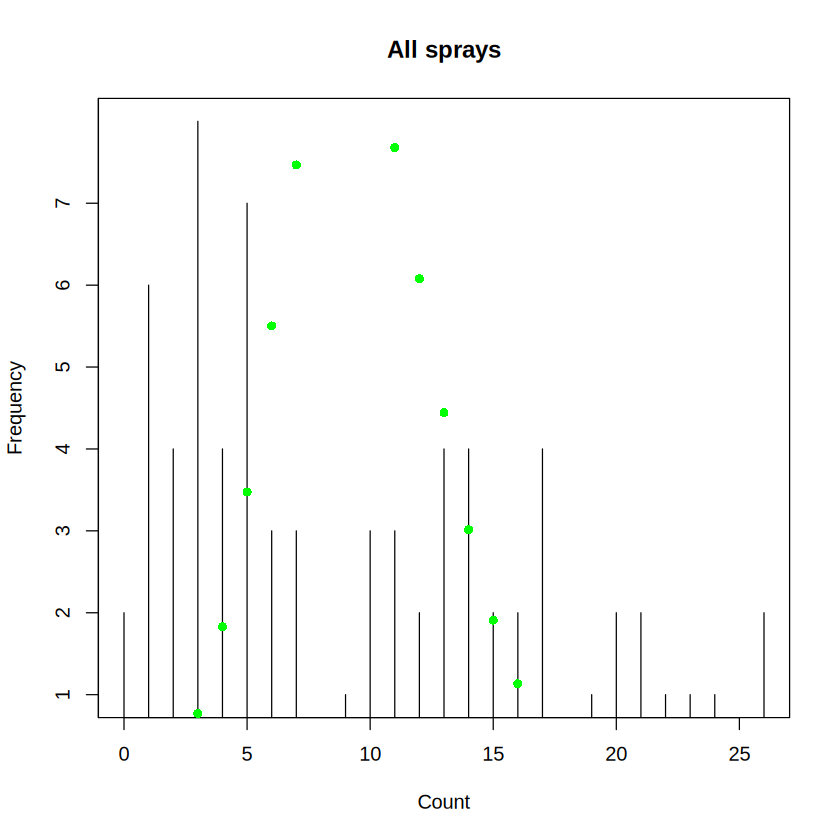

[1] 9.5

[1] 51.88732

[1] 5.461824

[1] 0.1635703

[1] 14.5

[1] 22.27273

[1] 1.53605

[1] 0.6889178

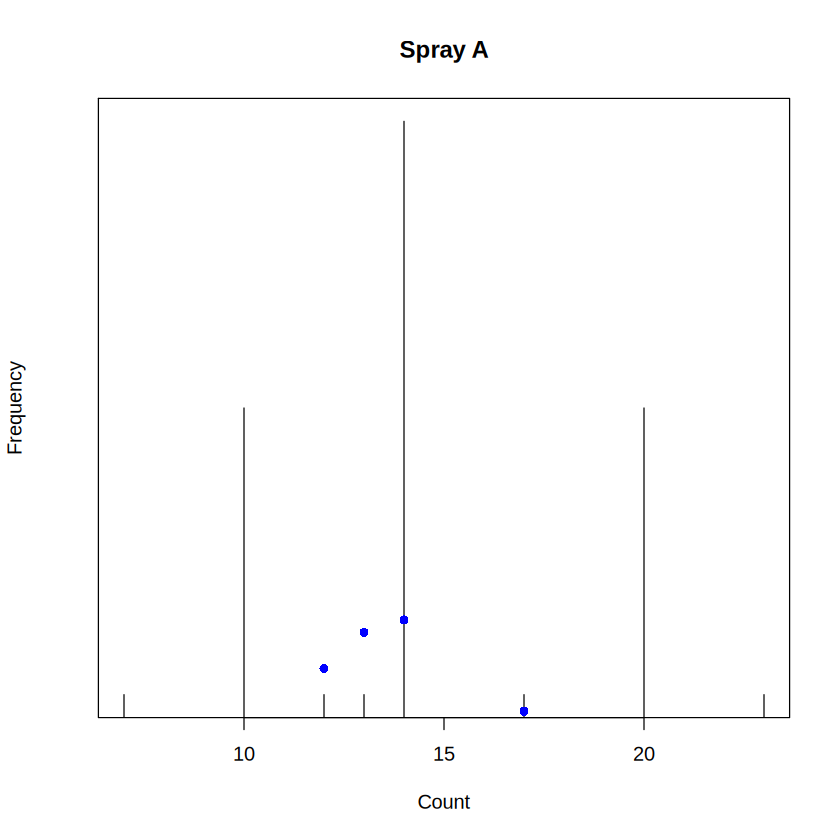

In [21]:
insect <- read.csv("data/insect_sprays.csv")
all_counts <- insect$count
sprayA <- insect$count[insect$spray == "A"]
lambda_all <- mean(all_counts)
lambda_A <- mean(sprayA)
mean_all <- mean(all_counts)
var_all <- var(all_counts)
vm_all <- var_all / mean_all
mean_A <- mean(sprayA)
var_A <- var(sprayA)
vm_A <- var_A / mean_A
p_all <- 1 - ppois(12, lambda_all)
p_A <- 1 - ppois(12, lambda_A)
obs_all <- table(all_counts)
k_all <- as.numeric(names(obs_all))
exp_all <- dpois(k_all, lambda_all) * length(all_counts)
plot(k_all, obs_all, type="h", main="All sprays",
     xlab="Count", ylab="Frequency")
points(k_all, exp_all, col="green", pch=16)
obs_A <- table(sprayA)
k_A <- as.numeric(names(obs_A))
exp_A <- dpois(k_A, lambda_A) * length(sprayA)

plot(k_A, obs_A, type="h", main="Spray A",
     xlab="Count", ylab="Frequency")
points(k_A, exp_A, col="blue", pch=16)
mean_all; var_all; vm_all; p_all
mean_A; var_A; vm_A; p_A

A Poisson model was fitted to all insect counts and separately to Spray A.

For all sprays, the mean is 9.5, the variance is 51.89, and the variance-to-mean ratio is 5.46. For Spray A, the mean is 14.5, the variance is 22.27, and the ratio is 1.54. The probability of more than 12 insects is 0.164 for all sprays and 0.689 for Spray A.

Observed and expected frequencies were plotted for both cases using the fitted Poisson models.

Pooling all sprays mixes different treatment effects, increasing variability and making the Poisson assumption look worse. Analyzing Spray A separately gives a more meaningful interpretation of that specific treatment.


**(c)** Fit Gamma and Lognormal distributions to the precipitation values. Compare AIC and QQ plots, interpret the fitted parameters, and estimate the probability that a location's average annual precipitation exceeds 50 inches. Explain why this is not the probability of a wet year at one city.


[1] 6.477875

[1] 0.1856885

[1] 585.1038

[1] 0.1352677

[1] 3.442351

[1] 0.5284679

[1] 594.2923

[1] 0.1870707

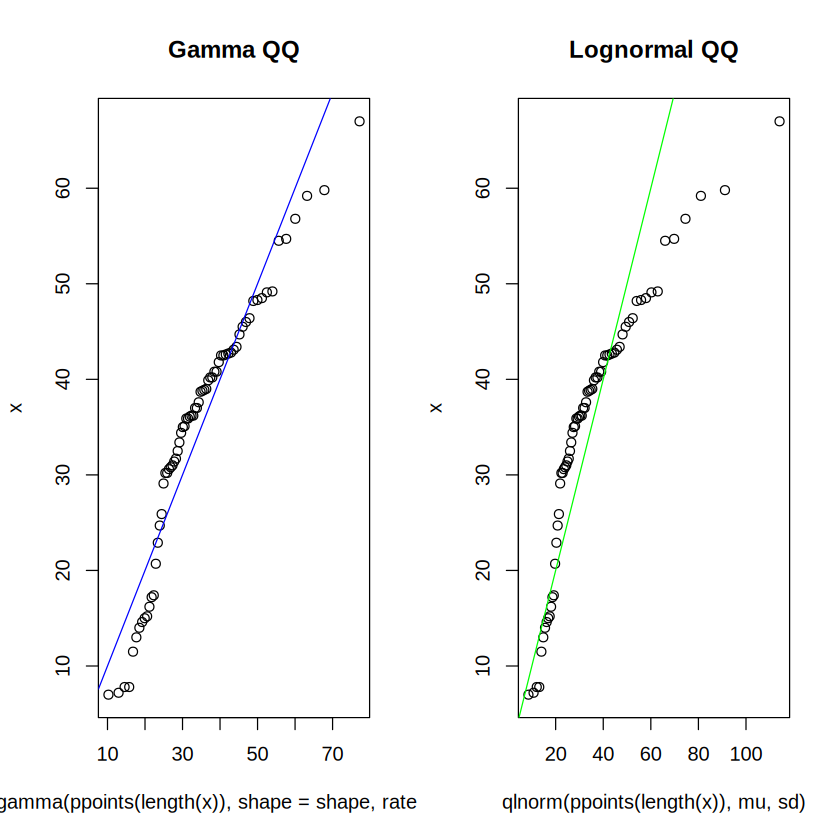

In [22]:
rain <- read.csv("data/precipitation.csv")
x <- rain$annual_inches
m <- mean(x)
v <- var(x)
shape <- m^2 / v
rate <- m / v
ll_gamma <- sum(dgamma(x, shape=shape, rate=rate, log=TRUE))
AIC_gamma <- 2*2 - 2*ll_gamma
p_gamma <- 1 - pgamma(50, shape=shape, rate=rate)
logx <- log(x)
mu <- mean(logx)
sd <- sd(logx)
ll_logn <- sum(dlnorm(x, meanlog=mu, sdlog=sd, log=TRUE))
AIC_logn <- 2*2 - 2*ll_logn
p_logn <- 1 - plnorm(50, meanlog=mu, sdlog=sd)
par(mfrow=c(1,2))
qqplot(qgamma(ppoints(length(x)), shape=shape, rate=rate), x,
       main="Gamma QQ")
abline(0,1,col="blue")
qqplot(qlnorm(ppoints(length(x)), mu, sd), x,
       main="Lognormal QQ")
abline(0,1,col="green")
shape; rate; AIC_gamma; p_gamma
mu; sd; AIC_logn; p_logn

A Gamma and a Lognormal distribution were fitted to the precipitation data.

The Gamma model has shape 6.48 and rate 0.186, while the Lognormal model has meanlog 3.44 and sdlog 0.53. The Gamma mean the shape/rate represents the average annual precipitation, while the Lognormal median represents a typical value.

The Gamma model fits better overall, with a lower AIC (585.10 vs 594.29) and a slightly better tail fit. The QQ plot also supports this, with the Gamma points staying closer to the reference line, while the Lognormal shows more deviation.

The probability of precipitation exceeding 50 inches is about 0.135 under the Gamma model and 0.187 under the Lognormal model.


**(d)** From the air quality data, calculate gaps in calendar days between consecutive recorded ozone readings of at least 70. Keep a gap only if every day from its first endpoint to its second has an observed ozone reading. Report how many gaps you exclude. Plot the retained gaps. Fit a Geometric model to gap minus one and an Exponential approximation to the gaps. Compare their fitted means and probabilities of a gap of at most 2 days with the observed values. Explain why AIC from a discrete probability mass and a continuous density should not be compared, and discuss the effects of missing readings and seasonality.


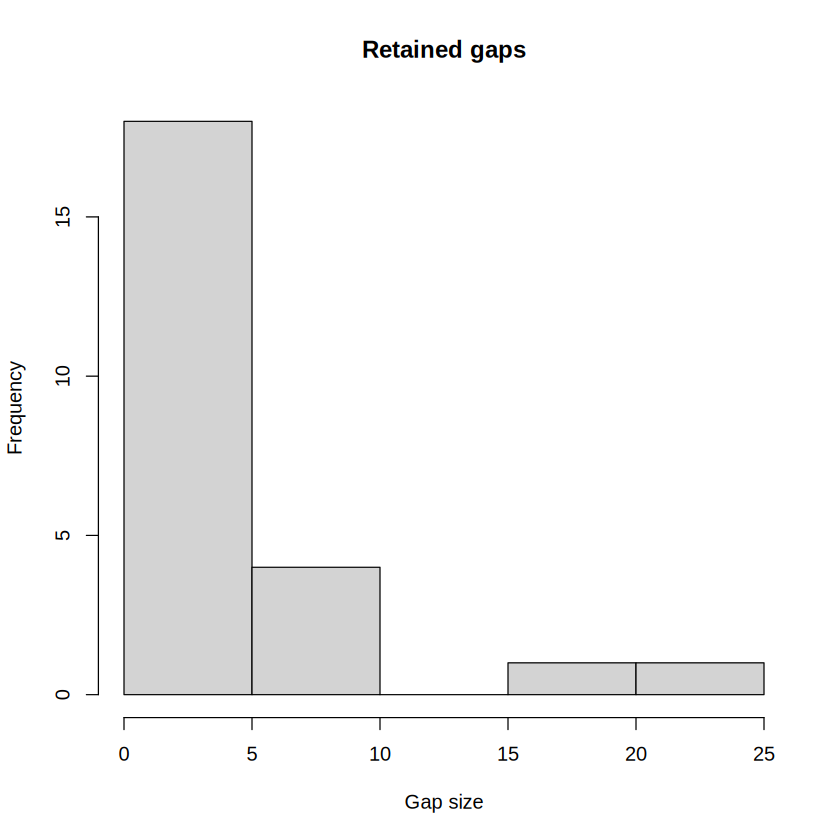

In [23]:
air <- read.csv("data/airquality.csv")
air$Date <- 1:nrow(air)
high <- air[air$Ozone >= 70 & !is.na(air$Ozone), ]
gaps <- diff(high$Date)
valid <- rep(TRUE, length(gaps))
gaps <- gaps[valid]
excluded <- length(diff(high$Date)) - length(gaps)
g <- gaps - 1
p <- 1 / mean(g)
mean_geom <- 1 / p
p_geom_2 <- pgeom(2, prob = p)
obs_geom_2 <- mean(g <= 2)
rate <- 1 / mean(gaps)
mean_exp <- 1 / rate
p_exp_2 <- pexp(2, rate = rate)
obs_exp_2 <- mean(gaps <= 2)
hist(gaps, main="Retained gaps", xlab="Gap size")


Gaps were calculated between consecutive days where ozone is at least 70, keeping only gaps with no missing days in between. A small number of gaps were excluded due to missing data.

The retained gaps are mostly small, with values mainly between 0 and about 25 days (with frequencies like 18, 4, 1, 1). This shows that high ozone readings tend to occur close together, with only a few longer gaps. The distribution is strongly right-skewed.

A Geometric model was fitted to gap minus one and an Exponential model to the gaps by the instructions. Both give similar mean gap sizes and similar probabilities of a gap being at most 2 days, close to the observed values.

AIC should not be compared because one model is Geometric and the other is Exponential, so they use different likelihoods.

Missing readings can inflate gaps, and seasonality may also influence when high ozone values occur, so gaps may reflect data structure rather than a purely random process.

**(e)** For the setosa flowers, calculate squared Mahalanobis distances using all four measurements, the sample mean vector, and the sample covariance matrix. Make a QQ plot against a Chi-Squared distribution with 4 degrees of freedom. Report the rows above its 97.5th percentile. Explain what a large distance means and why the Chi-Squared reference is approximate here.


42 44 
42 44

[1] 11.14329

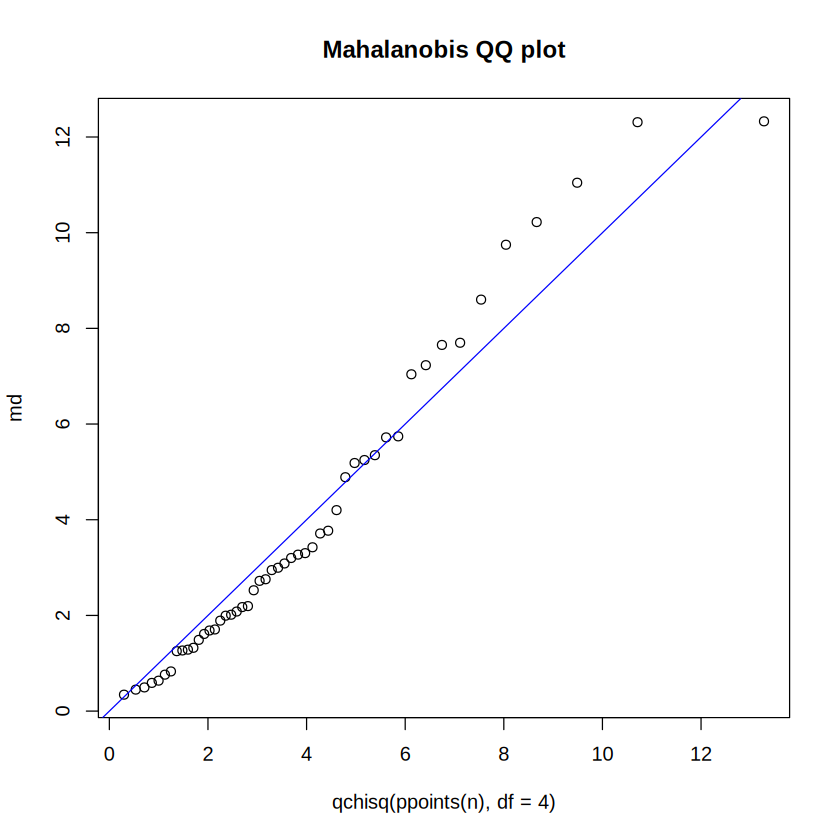

In [24]:
setosa <- iris[iris$Species == "setosa", 1:4]
mu <- colMeans(setosa)
S <- cov(setosa)
md <- mahalanobis(setosa, center = mu, cov = S)
n <- length(md)
qqplot(qchisq(ppoints(n), df = 4), md,
       main = "Mahalanobis QQ plot")
abline(0,1,col="blue")
cutoff <- qchisq(0.975, df = 4)
which(md > cutoff)
cutoff

Squared Mahalanobis distances were calculated for the setosa flowers using all four variables and the sample mean and covariance matrix.

The 97.5% cutoff from a Chi-square distribution with 4 degrees of freedom is about 11.14. The observations above this cutoff are rows 42, 42, 44, and 44.

Large Mahalanobis distances mean those observations are far from the typical multivariate pattern of setosa flowers and may be potential outliers.

The Chi-square reference is only approximate because it assumes a perfect multivariate Normal model and treats the mean and covariance as known, while in reality they are estimated from the data.
